# Notebook corrigé — Projet IA Travel Planning

Ce notebook remplace l'ancien brouillon `essaie.ipynb` par une version cohérente, exécutable et alignée avec le pipeline validé du projet.


## Note de correction

Cette version corrige les problèmes identifiés dans l'ancien notebook :

- suppression du chemin Google Colab `/content/...` ;
- suppression des dépendances lourdes non déclarées comme `spacy`, `transformers` et `xgboost` ;
- suppression des traitements manuels d'encodage et de standardisation avant le split train/test ;
- exclusion des variables post-séjour pour éviter la fuite de données ;
- intégration des transformations dans un pipeline `scikit-learn` ;
- traitement cohérent des valeurs manquantes et aberrantes ;
- comparaison propre des modèles et documentation des limites.


## 0. Contexte et périmètre

Une agence de voyages haut de gamme souhaite concevoir une solution IA capable de personnaliser la planification de séjours.

Le modèle principal étudié dans ce notebook vise à prédire `satisfaction_client` à partir des informations disponibles avant ou pendant la planification du voyage.

Variables post-séjour exclues du modèle principal :

- `imprevus` ;
- `reorganisation_necessaire` ;
- `respect_budget` ;
- `retour_client`.

Ces variables restent utiles pour l'analyse métier, mais elles ne doivent pas être utilisées comme entrées du modèle principal afin d'éviter une fuite de données.

## 1. Datasheet synthétique

| Élément | Description |
| --- | --- |
| Fichier | `data/Examen_travel_planning_dataset.csv` |
| Format | CSV |
| Volume attendu | Environ 1500 séjours |
| Domaine | Planification de voyages haut de gamme |
| Nature des données | Données synthétiques et anonymisées |
| Cible IA principale | `satisfaction_client` |
| Problème ML | Classification multi-classes de satisfaction |

Le fichier contient des informations sur le profil client, le budget, la destination, la saison, la durée, l'hébergement, le vol, la météo prévue, l'activité principale et les résultats observés après séjour.

## 2. Configuration

Cette section importe les bibliothèques nécessaires et limite le nombre de threads pour réduire la consommation mémoire sur une machine disposant de peu de RAM.

In [294]:
import os
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)
sns.set_theme(style="whitegrid")

## 3. Chargement du dataset brut

Le dataset brut est conservé dans `df_raw`. Les traitements de préparation seront appliqués sur une copie afin de garder une référence intacte aux données originales.

In [295]:
filename = "Examen_travel_planning_dataset.csv"
candidate_paths = [
    Path("data") / filename,
    Path("data/raw") / filename,
    Path("../data") / filename,
    Path("../data/raw") / filename,
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(f"Fichier introuvable : {filename}")

df_raw = pd.read_csv(data_path)

print(f"Fichier chargé : {data_path}")
print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
display(df_raw.head())

Fichier chargé : ..\data\Examen_travel_planning_dataset.csv
Dimensions : 1500 lignes x 15 colonnes


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client
0,1,solo,5548.90,Dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3.0,annulation,1,0,Séjour mitigé.
1,2,business,3288.27,Rome,printemps,12,hôtel,1524.09,variable,randonnée,4.0,aucun,0,1,Excellent séjour.
2,3,senior,13347.18,Bali,printemps,16,villa,881.94,ensoleillé,plage,5.0,météo,1,1,Excellent séjour.
3,4,couple,7049.42,Sydney,automne,17,appartement,844.39,nuageux,randonnée,3.0,météo,1,1,Séjour mitigé.
4,5,solo,7612.92,Paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2.0,retard_vol,1,1,Séjour mitigé.


In [ ]:
# Contr?le des valeurs n?gatives dans les colonnes num?riques du dataset brut
colonnes_numeriques = ["budget_total", "duree_jours", "prix_vol"]

valeurs_negatives = pd.DataFrame({
    "colonne": colonnes_numeriques,
    "nb_valeurs_negatives": [
        int((df_raw[col] < 0).sum()) for col in colonnes_numeriques
    ],
    "valeur_minimale": [
        df_raw[col].min() for col in colonnes_numeriques
    ],
})

display(valeurs_negatives)


## 4. Exploration rapide du brut

Cette exploration vérifie la structure du fichier avant toute modification : dimensions, types, valeurs manquantes et doublons.

In [297]:
resume_brut = pd.DataFrame({
    "type": df_raw.dtypes.astype(str),
    "valeurs_manquantes": df_raw.isna().sum(),
    "pourcentage_manquant": (df_raw.isna().sum() / len(df_raw) * 100).round(2),
    "valeurs_uniques": df_raw.nunique(dropna=True),
})

display(resume_brut)

print("Doublons exacts :", int(df_raw.duplicated().sum()))
print("Doublons trip_id :", int(df_raw["trip_id"].duplicated().sum()))

,type,valeurs_manquantes,pourcentage_manquant,valeurs_uniques
trip_id,int64,0,0.00,1500
client_type,object,0,0.00,5
budget_total,float64,40,2.67,1419
destination,object,0,0.00,8
saison,object,0,0.00,4
duree_jours,int64,0,0.00,23
type_hebergement,object,36,2.40,4
prix_vol,float64,53,3.53,1429
meteo_prevue,object,39,2.60,4
activite_principale,object,48,3.20,5


Doublons exacts : 0
Doublons trip_id : 0


,valeurs_manquantes,pourcentage
prix_vol,53,3.53
imprevus,53,3.53
activite_principale,48,3.20
budget_total,40,2.67
meteo_prevue,39,2.60
type_hebergement,36,2.40
satisfaction_client,25,1.67
retour_client,25,1.67


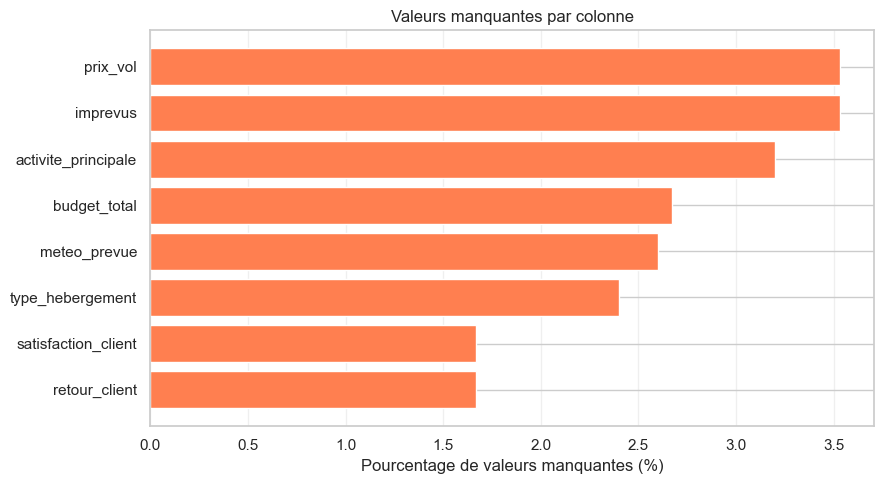

In [298]:
missing_summary = (
    df_raw.isna().sum()
    .to_frame("valeurs_manquantes")
)
missing_summary["pourcentage"] = (missing_summary["valeurs_manquantes"] / len(df_raw) * 100).round(2)
missing_summary = missing_summary[missing_summary["valeurs_manquantes"] > 0].sort_values("valeurs_manquantes", ascending=False)

display(missing_summary)

if not missing_summary.empty:
    plt.figure(figsize=(9, 5))
    plt.barh(missing_summary.index[::-1], missing_summary["pourcentage"][::-1], color="coral")
    plt.xlabel("Pourcentage de valeurs manquantes (%)")
    plt.title("Valeurs manquantes par colonne")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Analyse métier de cohérence du dataset brut

Cette section reprend l'analyse métier détaillée du notebook `analyse_métier.ipynb`.

Elle est placée avant le nettoyage pour distinguer :

- les incohérences critiques à traiter avant la modélisation ;
- les points de vigilance à documenter ;
- les variables à exclure du modèle principal pour éviter la fuite de données.


In [299]:
# Fonctions utilitaires utilisées dans tout le notebook

def normaliser_texte(serie):
    """Standardise les textes pour faciliter les comparaisons métier."""
    return serie.fillna("").astype(str).str.strip().str.lower()


def afficher_cas(df_cas, colonnes=None, n=10):
    """Affiche le nombre de cas détectés puis un échantillon lisible."""
    print(f"Nombre de cas détectés : {len(df_cas)}")
    if len(df_cas) == 0:
        print("Aucun cas à afficher.")
        return

    if colonnes is not None:
        display(df_cas[colonnes].head(n))
    else:
        display(df_cas.head(n))


colonnes_principales = [
    "trip_id", "client_type", "budget_total", "destination", "saison",
    "duree_jours", "type_hebergement", "prix_vol", "meteo_prevue",
    "activite_principale", "satisfaction_client", "imprevus",
    "reorganisation_necessaire", "respect_budget"
]

### 5.1. Unicité des séjours

### Observation métier

Chaque ligne représente un séjour passé. La colonne `trip_id` doit donc identifier un séjour unique.

Un doublon sur `trip_id` pourrait fausser l'analyse car un même séjour serait compté plusieurs fois.

In [300]:
doublons_trip_id = df_raw[df_raw["trip_id"].duplicated(keep=False)].copy()
doublons_lignes = df_raw[df_raw.duplicated(keep=False)].copy()

print("Doublons sur trip_id :")
afficher_cas(doublons_trip_id, colonnes_principales)

print("\nDoublons exacts sur toutes les colonnes :")
afficher_cas(doublons_lignes, colonnes_principales)

Doublons sur trip_id :
Nombre de cas détectés : 0
Aucun cas à afficher.

Doublons exacts sur toutes les colonnes :
Nombre de cas détectés : 0
Aucun cas à afficher.


### 5.2. Cohérence de la satisfaction client

### Observation métier

Le cahier des charges indique que `satisfaction_client` est un score de 1 à 5.

Les valeurs inférieures à 1, supérieures à 5 ou manquantes sont donc incohérentes avec la définition officielle de la variable.

Ces cas doivent être corrigés, exclus ou documentés avant d'utiliser `satisfaction_client` comme cible IA.

In [301]:
satisfaction_invalide = df_raw[
    df_raw["satisfaction_client"].isna()
    | ~df_raw["satisfaction_client"].between(1, 5)
].copy()

afficher_cas(
    satisfaction_invalide,
    ["trip_id", "client_type", "destination", "satisfaction_client", "imprevus", "retour_client"]
)

Nombre de cas détectés : 30


,trip_id,client_type,destination,satisfaction_client,imprevus,retour_client
765,766,couple,Bali,NaN,annulation,Une expérience inoubliable.
771,772,solo,Tokyo,NaN,bagages,À éviter.
778,779,couple,Rome,NaN,annulation,Déçu par l'organisation.
800,801,couple,Paris,6.0,aucun,Très bon rapport qualité-prix.
801,802,famille,Dubaï,NaN,aucun,Une expérience inoubliable.
811,812,solo,Rome,6.0,aucun,"Très satisfait, je recommande."
812,813,solo,Bali,0.0,retard_vol,À éviter.
826,827,couple,Sydney,NaN,météo,Déçu par l'organisation.
835,836,famille,Dubaï,NaN,météo,Excellent séjour.
858,859,famille,Paris,NaN,retard_vol,Très mauvaise expérience.


### 5.3. Prix du vol supérieur au budget total

### Observation métier

Le `budget_total` représente le budget global du séjour.

Si `prix_vol > budget_total`, le coût du vol dépasse déjà le budget disponible. C'est une incohérence forte ou un séjour impossible à financer sans dépassement.

Le cas est encore plus problématique si `respect_budget = 1`, car cela indique que le budget aurait été respecté malgré un vol supérieur au budget total.

In [302]:
vol_superieur_budget = df_raw[
    df_raw["prix_vol"].notna()
    & df_raw["budget_total"].notna()
    & (df_raw["prix_vol"] > df_raw["budget_total"])
].copy()

vol_superieur_budget["ecart_vol_budget"] = (
    vol_superieur_budget["prix_vol"] - vol_superieur_budget["budget_total"]
).round(2)

print("Tous les cas où le prix du vol dépasse le budget total :")
afficher_cas(
    vol_superieur_budget.sort_values("ecart_vol_budget", ascending=False),
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

print("\nCas contradictoires : prix_vol > budget_total ET respect_budget = 1")
vol_superieur_budget_respecte = vol_superieur_budget[vol_superieur_budget["respect_budget"] == 1]
afficher_cas(
    vol_superieur_budget_respecte,
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

Tous les cas où le prix du vol dépasse le budget total :
Nombre de cas détectés : 52


,trip_id,client_type,destination,budget_total,prix_vol,ecart_vol_budget,respect_budget
825,826,couple,Rome,500.00,4500.00,4000.00,0
1388,1389,business,Rome,1052.28,4500.00,3447.72,0
1434,1435,business,Paris,500.00,1554.63,1054.63,0
1384,1385,famille,Lisbonne,4152.93,5200.00,1047.07,1
902,903,famille,Rome,500.00,1535.25,1035.25,0
1413,1414,famille,Tokyo,637.34,1593.89,956.55,0
1144,1145,famille,Dubaï,500.00,1443.55,943.55,0
948,949,couple,New York,500.00,1432.13,932.13,0
1402,1403,business,New York,500.00,1426.89,926.89,0
1206,1207,senior,Lisbonne,500.00,1352.70,852.70,0



Cas contradictoires : prix_vol > budget_total ET respect_budget = 1
Nombre de cas détectés : 5


,trip_id,client_type,destination,budget_total,prix_vol,ecart_vol_budget,respect_budget
7,8,couple,Rome,1173.19,1694.67,521.48,1
216,217,business,Rome,1147.25,1438.08,290.83,1
230,231,business,Dubaï,1388.56,1444.72,56.16,1
887,888,solo,Dubaï,380.00,1023.17,643.17,1
1384,1385,famille,Lisbonne,4152.93,5200.00,1047.07,1


### 5.4. Cohérence entre client business et activité principale

### Observation métier

Un client `business` peut avoir une activité principale `business`, mais ce n'est pas obligatoire : il peut aussi prolonger son séjour avec de la culture, de la gastronomie ou une activité de loisir.

Ce contrôle n'est donc pas une erreur automatique. C'est un point de vigilance pour vérifier si le dataset décrit bien le comportement attendu des voyageurs professionnels.

In [303]:
client_type_norm = normaliser_texte(df_raw["client_type"])
activite_norm = normaliser_texte(df_raw["activite_principale"])

business_activite_non_business = df_raw[
    (client_type_norm == "business")
    & (activite_norm != "business")
    & (activite_norm != "")
].copy()

non_business_activite_business = df_raw[
    (client_type_norm != "business")
    & (client_type_norm != "")
    & (activite_norm == "business")
].copy()

print("Clients business avec une activité principale non-business :")
afficher_cas(
    business_activite_non_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

print("\nClients non-business avec une activité principale business :")
afficher_cas(
    non_business_activite_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

Clients business avec une activité principale non-business :
Nombre de cas détectés : 200


,trip_id,client_type,destination,saison,activite_principale,budget_total,satisfaction_client
1,2,business,Rome,printemps,randonnée,3288.27,4.0
14,15,business,New York,été,randonnée,12985.57,4.0
19,20,business,Tokyo,printemps,plage,10416.72,3.0
27,28,business,Lisbonne,été,culture,10572.54,5.0
29,30,business,Dubaï,été,culture,2403.24,4.0
34,35,business,Bali,hiver,gastronomie,7427.80,1.0
37,38,business,New York,printemps,plage,13023.12,5.0
40,41,business,Tokyo,été,culture,5227.96,2.0
41,42,business,Tokyo,été,randonnée,5142.10,5.0
44,45,business,Tokyo,été,culture,4100.91,3.0



Clients non-business avec une activité principale business :
Nombre de cas détectés : 122


,trip_id,client_type,destination,saison,activite_principale,budget_total,satisfaction_client
10,11,senior,Bali,automne,business,12845.33,5.0
15,16,solo,Rome,automne,business,6125.88,1.0
16,17,senior,New York,hiver,business,8193.32,2.0
20,21,famille,Bali,automne,business,8186.44,2.0
23,24,solo,Dubaï,automne,business,13391.63,5.0
25,26,couple,Lisbonne,hiver,business,954.98,1.0
42,43,solo,New York,printemps,business,13696.57,2.0
47,48,couple,Lisbonne,hiver,business,9297.44,5.0
71,72,solo,Sydney,hiver,business,2187.78,3.0
129,130,solo,Tokyo,hiver,business,4161.07,3.0


### 5.5. Activités extérieures et météo risquée

### Observation métier

L'activité `randonnée` est sensible à la météo.

Si la météo prévue est `pluie` ou `variable`, le séjour peut nécessiter une alternative ou un plan de réorganisation.

Ce n'est pas forcément une erreur, mais c'est une information importante pour l'anticipation des imprévus.

In [304]:
meteo_norm = normaliser_texte(df_raw["meteo_prevue"])
activites_exterieures = ["randonnée", "randonnee"]
meteos_risquees = ["pluie", "variable"]

activites_meteo_risque = df_raw[
    activite_norm.isin(activites_exterieures)
    & meteo_norm.isin(meteos_risquees)
].copy()

afficher_cas(
    activites_meteo_risque,
    ["trip_id", "destination", "saison", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

Nombre de cas détectés : 75


,trip_id,destination,saison,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
1,2,Rome,printemps,variable,randonnée,aucun,0,4.0
7,8,Rome,été,pluie,randonnée,annulation,1,2.0
9,10,New York,automne,variable,randonnée,météo,1,1.0
14,15,New York,été,pluie,randonnée,retard_vol,1,4.0
32,33,Dubaï,printemps,variable,randonnée,bagages,1,1.0
38,39,Lisbonne,été,pluie,randonnée,retard_vol,1,1.0
51,52,Paris,printemps,variable,randonnée,bagages,1,2.0
54,55,Dubaï,automne,variable,randonnée,retard_vol,1,2.0
157,158,Paris,printemps,variable,randonnée,aucun,0,3.0
169,170,Lisbonne,hiver,variable,randonnée,aucun,0,1.0


### 5.6. Cohérence entre imprévus et réorganisation

### Observation métier

La variable `reorganisation_necessaire` doit normalement être liée aux imprévus.

Deux situations sont à contrôler :

1. `imprevus = aucun` mais `reorganisation_necessaire = 1` : cas suspect, car il y a une réorganisation sans imprévu déclaré ;
2. `imprevus != aucun` mais `reorganisation_necessaire = 0` : cas possible si l'imprévu est mineur, mais à vérifier.

In [305]:
imprevus_norm = normaliser_texte(df_raw["imprevus"])

aucun_imprevu_mais_reorganisation = df_raw[
    (imprevus_norm == "aucun")
    & (df_raw["reorganisation_necessaire"] == 1)
].copy()

imprevu_sans_reorganisation = df_raw[
    (imprevus_norm != "")
    & (imprevus_norm != "aucun")
    & (df_raw["reorganisation_necessaire"] == 0)
].copy()

print("Aucun imprévu déclaré mais réorganisation nécessaire :")
afficher_cas(
    aucun_imprevu_mais_reorganisation,
    ["trip_id", "destination", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

print("\nImprévu déclaré mais aucune réorganisation :")
afficher_cas(
    imprevu_sans_reorganisation,
    ["trip_id", "destination", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

Aucun imprévu déclaré mais réorganisation nécessaire :
Nombre de cas détectés : 19


,trip_id,destination,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
78,79,Bali,ensoleillé,gastronomie,aucun,1,3.0
135,136,Bali,ensoleillé,plage,aucun,1,3.0
136,137,New York,nuageux,business,aucun,1,4.0
262,263,Lisbonne,pluie,gastronomie,aucun,1,3.0
363,364,Bali,ensoleillé,gastronomie,aucun,1,5.0
395,396,New York,ensoleillé,randonnée,aucun,1,2.0
417,418,Rome,pluie,business,aucun,1,2.0
473,474,Dubaï,pluie,business,aucun,1,2.0
490,491,Lisbonne,nuageux,culture,aucun,1,5.0
496,497,Paris,pluie,plage,aucun,1,2.0



Imprévu déclaré mais aucune réorganisation :
Nombre de cas détectés : 335


,trip_id,destination,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
63,64,Lisbonne,ensoleillé,plage,météo,0,3.0
66,67,Rome,ensoleillé,business,météo,0,4.0
69,70,Tokyo,ensoleillé,randonnée,retard_vol,0,2.0
71,72,Sydney,variable,business,météo,0,3.0
72,73,Lisbonne,ensoleillé,gastronomie,retard_vol,0,1.0
79,80,Tokyo,nuageux,randonnée,bagages,0,2.0
81,82,New York,variable,gastronomie,météo,0,3.0
86,87,Dubaï,pluie,culture,retard_vol,0,1.0
90,91,Paris,ensoleillé,culture,annulation,0,3.0
91,92,Bali,variable,culture,retard_vol,0,4.0


### 5.7. Imprévus et satisfaction faible

### Observation métier

Un imprévu peut réduire la satisfaction client.

Les cas où `imprevus != aucun` et `satisfaction_client <= 2` sont cohérents métier, mais importants pour comprendre les facteurs d'insatisfaction.

Ils peuvent alimenter l'analyse explicative, mais il faut éviter d'utiliser les imprévus comme variable d'entrée si l'objectif est de prédire la satisfaction avant le départ.

In [306]:
imprevus_satisfaction_faible = df_raw[
    (imprevus_norm != "")
    & (imprevus_norm != "aucun")
    & df_raw["satisfaction_client"].notna()
    & (df_raw["satisfaction_client"] <= 2)
].copy()

afficher_cas(
    imprevus_satisfaction_faible,
    ["trip_id", "client_type", "destination", "imprevus", "reorganisation_necessaire", "respect_budget", "satisfaction_client", "retour_client"]
)

Nombre de cas détectés : 573


,trip_id,client_type,destination,imprevus,reorganisation_necessaire,respect_budget,satisfaction_client,retour_client
4,5,solo,Paris,retard_vol,1,1,2.0,Séjour mitigé.
7,8,couple,Rome,annulation,1,1,2.0,Séjour mitigé.
8,9,couple,Paris,annulation,1,0,2.0,Séjour mitigé.
9,10,solo,New York,météo,1,0,1.0,Séjour mitigé.
11,12,senior,Paris,retard_vol,1,0,2.0,Séjour mitigé.
12,13,famille,New York,météo,1,1,1.0,Séjour mitigé.
13,14,solo,Sydney,annulation,1,1,2.0,Séjour mitigé.
22,23,famille,Lisbonne,bagages,1,0,1.0,Séjour mitigé.
25,26,couple,Lisbonne,retard_vol,1,1,1.0,Séjour mitigé.
28,29,solo,Bali,retard_vol,1,0,2.0,Séjour mitigé.


### 5.8. Risque de fuite de données pour la modélisation

### Observation métier

Certaines colonnes décrivent le résultat du séjour après coup :

- `imprevus` ;
- `reorganisation_necessaire` ;
- `respect_budget` ;
- `retour_client`.

Si le modèle doit prédire la satisfaction avant le départ, ces variables ne doivent pas être utilisées comme entrées, car elles ne sont pas connues au moment de la recommandation.

Elles peuvent cependant servir à une analyse après séjour ou à un modèle secondaire d'amélioration continue.

In [307]:
colonnes_post_sejour = ["imprevus", "reorganisation_necessaire", "respect_budget", "retour_client", "satisfaction_client"]
display(df_raw[["trip_id", *colonnes_post_sejour]].head(10))

,trip_id,imprevus,reorganisation_necessaire,respect_budget,retour_client,satisfaction_client
0,1,annulation,1,0,Séjour mitigé.,3.0
1,2,aucun,0,1,Excellent séjour.,4.0
2,3,météo,1,1,Excellent séjour.,5.0
3,4,météo,1,1,Séjour mitigé.,3.0
4,5,retard_vol,1,1,Séjour mitigé.,2.0
5,6,météo,1,1,Excellent séjour.,5.0
6,7,météo,1,1,Excellent séjour.,5.0
7,8,annulation,1,1,Séjour mitigé.,2.0
8,9,annulation,1,0,Séjour mitigé.,2.0
9,10,météo,1,0,Séjour mitigé.,1.0


### 5.9. Synthèse des contrôles

Ce tableau résume les contrôles réalisés et le nombre de cas détectés.

Il sert de base pour décider quoi corriger, quoi conserver et quoi documenter avant la modélisation.

In [308]:
synthese_controles = pd.DataFrame([
    {
        "controle": "Doublons trip_id",
        "nb_cas": len(doublons_trip_id),
        "niveau": "Incohérence forte si > 0",
        "action_recommandee": "Supprimer dans tout les cas"
    },
    {
        "controle": "Satisfaction hors échelle ou manquante",
        "nb_cas": len(satisfaction_invalide),
        "niveau": "Incohérence forte",
        "action_recommandee": "Corriger, exclure ou imputer selon justification"
    },
    {
        "controle": "Prix du vol supérieur au budget total",
        "nb_cas": len(vol_superieur_budget),
        "niveau": "Incohérence forte",
        "action_recommandee": "Contrôler budget_total, prix_vol et respect_budget"
    },
    {
        "controle": "Prix du vol > budget total et respect_budget = 1",
        "nb_cas": len(vol_superieur_budget_respecte),
        "niveau": "Contradiction métier",
        "action_recommandee": "Corriger respect_budget ou les montants"
    },
    {
        "controle": "Client business avec activité non-business",
        "nb_cas": len(business_activite_non_business),
        "niveau": "Point de vigilance",
        "action_recommandee": "Vérifier si le séjour mixte business/loisir est attendu"
    },
    {
        "controle": "Client non-business avec activité business",
        "nb_cas": len(non_business_activite_business),
        "niveau": "Point de vigilance",
        "action_recommandee": "Vérifier la définition de l'activité principale"
    },
    {
        "controle": "Randonnée avec météo risquée",
        "nb_cas": len(activites_meteo_risque),
        "niveau": "Signal métier utile",
        "action_recommandee": "Créer une variable meteo_risque ciblée sur la randonnée"
    },
    {
        "controle": "Aucun imprévu mais réorganisation nécessaire",
        "nb_cas": len(aucun_imprevu_mais_reorganisation),
        "niveau": "Cas suspect",
        "action_recommandee": "Contrôler la cohérence entre imprevus et reorganisation_necessaire"
    },
    {
        "controle": "Imprévu déclaré sans réorganisation",
        "nb_cas": len(imprevu_sans_reorganisation),
        "niveau": "Point de vigilance",
        "action_recommandee": "Conserver si imprévu mineur, sinon corriger"
    },
    {
        "controle": "Imprévu avec satisfaction faible",
        "nb_cas": len(imprevus_satisfaction_faible),
        "niveau": "Signal explicatif",
        "action_recommandee": "Utiliser pour comprendre l'insatisfaction, attention à la fuite de données"
    },
])

display(synthese_controles)

,controle,nb_cas,niveau,action_recommandee
0,Doublons trip_id,0,Incohérence forte si > 0,Supprimer dans tout les cas
1,Satisfaction hors échelle ou manquante,30,Incohérence forte,"Corriger, exclure ou imputer selon justification"
2,Prix du vol supérieur au budget total,52,Incohérence forte,"Contrôler budget_total, prix_vol et respect_bu..."
3,Prix du vol > budget total et respect_budget = 1,5,Contradiction métier,Corriger respect_budget ou les montants
4,Client business avec activité non-business,200,Point de vigilance,Vérifier si le séjour mixte business/loisir es...
5,Client non-business avec activité business,122,Point de vigilance,Vérifier la définition de l'activité principale
6,Randonnée avec météo risquée,75,Signal métier utile,Créer une variable meteo_risque ciblée sur la ...
7,Aucun imprévu mais réorganisation nécessaire,19,Cas suspect,Contrôler la cohérence entre imprevus et reorg...
8,Imprévu déclaré sans réorganisation,335,Point de vigilance,"Conserver si imprévu mineur, sinon corriger"
9,Imprévu avec satisfaction faible,573,Signal explicatif,"Utiliser pour comprendre l'insatisfaction, att..."


### 5.10. Sélection des incohérences à traiter avant modélisation

Toutes les observations précédentes ne doivent pas être corrigées. Certaines sont des signaux métier utiles, d'autres sont des incohérences qui peuvent dégrader directement le modèle.

Pour le modèle principal envisagé, la cible est `satisfaction_client`. On distingue donc :

- les problèmes à traiter obligatoirement avant l'entraînement ;
- les variables à exclure pour éviter la fuite de données ;
- les points de vigilance à conserver ou transformer en variables métier.


In [309]:
selection_traitement_modele = pd.DataFrame([
    {
        "controle": "Satisfaction hors échelle ou manquante",
        "impact_modele": "Impact critique sur la cible y",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Supprimer les lignes sans cible ou hors échelle 1-5, sauf justification métier de recodage"
    },
    {
        "controle": "Prix du vol supérieur au budget total",
        "impact_modele": "Crée des relations budgétaires impossibles et fausse les ratios",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Identifier les cas, corriger si possible ; sinon exclure ou créer un indicateur d'anomalie"
    },
    {
        "controle": "Prix du vol > budget total et respect_budget = 1",
        "impact_modele": "Contradiction métier forte entre budget et résultat",
        "decision": "Traiter obligatoirement si respect_budget est utilisé",
        "traitement_recommande": "Corriger respect_budget ou exclure ces lignes des modèles utilisant cette variable"
    },
    {
        "controle": "Variables post-séjour : imprevus, reorganisation_necessaire, respect_budget, retour_client",
        "impact_modele": "Risque majeur de fuite de données si la prédiction est faite avant le départ",
        "decision": "Exclure des features du modèle principal",
        "traitement_recommande": "Ne pas les mettre dans X pour prédire satisfaction_client avant voyage ; les garder pour l'analyse explicative"
    },
])

display(selection_traitement_modele)

,controle,impact_modele,decision,traitement_recommande
0,Satisfaction hors échelle ou manquante,Impact critique sur la cible y,Traiter obligatoirement,Supprimer les lignes sans cible ou hors échell...
1,Prix du vol supérieur au budget total,Crée des relations budgétaires impossibles et ...,Traiter obligatoirement,"Identifier les cas, corriger si possible ; sin..."
2,Prix du vol > budget total et respect_budget = 1,Contradiction métier forte entre budget et rés...,Traiter obligatoirement si respect_budget est ...,Corriger respect_budget ou exclure ces lignes ...
3,"Variables post-séjour : imprevus, reorganisati...",Risque majeur de fuite de données si la prédic...,Exclure des features du modèle principal,Ne pas les mettre dans X pour prédire satisfac...


#### Observations non traitées comme erreurs

Les contrôles suivants ne sont pas corrigés automatiquement car ils peuvent représenter des comportements métier réels :

- `client business` avec activité non-business : possible séjour mixte business/loisir ;
- `client non-business` avec activité business : possible voyage personnel avec objectif professionnel ;
- activité extérieure avec météo risquée : signal utile pour créer `meteo_risque`, pas une erreur ;
- imprévu avec satisfaction faible : signal explicatif, pas une incohérence ;
- imprévu sans réorganisation : possible si l'imprévu est mineur.


### 5.11. Conclusion métier

Le dataset est exploitable pour un prototype IA, mais plusieurs points doivent être documentés avant la modélisation :

- la cible `satisfaction_client` doit être nettoyée car certaines valeurs ne respectent pas l'échelle 1 à 5 ;
- les contradictions fortes liées au budget doivent être traitées ;
- les variables post-séjour doivent être séparées des variables disponibles avant le départ pour éviter la fuite de données ;
- les contrôles météo, activité, budget journalier et type client peuvent devenir des variables utiles de feature engineering.

Ces observations justifient une étape de préparation des données avant la création du modèle IA.

## 6. Incohérences critiques retenues pour la modélisation

L'analyse métier détaillée est documentée dans `notebooks/analyse_métier.ipynb`.

Pour le modèle principal, seules les incohérences ayant un impact direct sur l'entraînement sont traitées ici :

1. `satisfaction_client` manquante ou hors échelle `1 à 5` ;
2. `prix_vol > budget_total` ;
3. `prix_vol > budget_total` avec `respect_budget = 1`, déjà inclus dans le point précédent ;
4. variables post-séjour à exclure des variables explicatives.

In [310]:
controle_satisfaction = df_raw[
    df_raw["satisfaction_client"].isna()
    | ~df_raw["satisfaction_client"].between(1, 5)
].copy()

controle_prix_budget = df_raw[
    df_raw["prix_vol"].notna()
    & df_raw["budget_total"].notna()
    & (df_raw["prix_vol"] > df_raw["budget_total"])
].copy()

controle_prix_budget_respect = controle_prix_budget[
    controle_prix_budget["respect_budget"] == 1
].copy()

synthese_incoherences = pd.DataFrame([
    {
        "controle": "satisfaction_client manquante ou hors échelle 1-5",
        "nb_lignes": len(controle_satisfaction),
        "traitement": "suppression des lignes concernées"
    },
    {
        "controle": "prix_vol > budget_total",
        "nb_lignes": len(controle_prix_budget),
        "traitement": "suppression des lignes concernées"
    },
    {
        "controle": "prix_vol > budget_total et respect_budget = 1",
        "nb_lignes": len(controle_prix_budget_respect),
        "traitement": "déjà couvert par le contrôle prix_vol > budget_total"
    },
    {
        "controle": "variables post-séjour dans les features",
        "nb_lignes": np.nan,
        "traitement": "exclusion de X pour éviter la fuite de données"
    },
])

display(synthese_incoherences)

,controle,nb_lignes,traitement
0,satisfaction_client manquante ou hors échelle 1-5,30.0,suppression des lignes concernées
1,prix_vol > budget_total,52.0,suppression des lignes concernées
2,prix_vol > budget_total et respect_budget = 1,5.0,déjà couvert par le contrôle prix_vol > budget...
3,variables post-séjour dans les features,NaN,exclusion de X pour éviter la fuite de données


In [311]:
print("Cas satisfaction_client à exclure :")
display(
    controle_satisfaction[
        ["trip_id", "client_type", "destination", "satisfaction_client", "imprevus", "retour_client"]
    ].head(10)
)

print("Cas prix_vol > budget_total à exclure :")
display(
    controle_prix_budget[
        ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "respect_budget", "satisfaction_client"]
    ].sort_values(["budget_total", "prix_vol"]).head(10)
)

Cas satisfaction_client à exclure :


,trip_id,client_type,destination,satisfaction_client,imprevus,retour_client
765,766,couple,Bali,NaN,annulation,Une expérience inoubliable.
771,772,solo,Tokyo,NaN,bagages,À éviter.
778,779,couple,Rome,NaN,annulation,Déçu par l'organisation.
800,801,couple,Paris,6.0,aucun,Très bon rapport qualité-prix.
801,802,famille,Dubaï,NaN,aucun,Une expérience inoubliable.
811,812,solo,Rome,6.0,aucun,"Très satisfait, je recommande."
812,813,solo,Bali,0.0,retard_vol,À éviter.
826,827,couple,Sydney,NaN,météo,Déçu par l'organisation.
835,836,famille,Dubaï,NaN,météo,Excellent séjour.
858,859,famille,Paris,NaN,retard_vol,Très mauvaise expérience.


Cas prix_vol > budget_total à exclure :


,trip_id,client_type,destination,budget_total,prix_vol,respect_budget,satisfaction_client
1451,1452,couple,Rome,380.0,840.02,0,3.0
887,888,solo,Dubaï,380.0,1023.17,1,3.0
868,869,solo,Tokyo,450.0,1206.41,0,2.0
1044,1045,senior,Bali,500.0,736.74,0,2.0
863,864,business,Tokyo,500.0,751.24,0,4.0
818,819,famille,New York,500.0,826.62,0,4.0
1021,1022,couple,Tokyo,500.0,841.02,0,5.0
1029,1030,senior,New York,500.0,843.01,0,3.0
1347,1348,business,New York,500.0,907.05,0,4.0
823,824,couple,Bali,500.0,907.54,0,3.0


## 7. Préparation des données

Cette étape transforme le dataset brut nettoyé en dataset exploitable pour la modélisation.

Elle comprend :

1. le traitement des incohérences critiques ;
2. le traitement des valeurs manquantes restantes ;
3. le traitement des valeurs aberrantes numériques.

Les traitements sont appliqués avant le feature engineering afin de créer les nouvelles variables sur une base plus cohérente.


### 7.1 Traitement des incohérences critiques

Les lignes sans cible exploitable ou présentant une incohérence métier forte sont supprimées.

La cible `satisfaction_client` n'est pas imputée, car inventer une valeur cible biaiserait l'apprentissage supervisé.


In [312]:
df_model = df_raw.copy()

nb_initial = len(df_model)

# 1. Cible valide uniquement : satisfaction_client entre 1 et 5.
mask_target_valid = (
    df_model["satisfaction_client"].notna()
    & df_model["satisfaction_client"].between(1, 5)
)
df_model = df_model[mask_target_valid].copy()
nb_after_target = len(df_model)

# 2. Cohérence budgétaire : le prix du vol ne doit pas dépasser le budget total.
mask_budget_valid = (
    df_model["prix_vol"].isna()
    | df_model["budget_total"].isna()
    | (df_model["prix_vol"] <= df_model["budget_total"])
)
df_model = df_model[mask_budget_valid].copy()
nb_after_budget = len(df_model)

rapport_nettoyage = pd.DataFrame([
    {
        "etape": "Dataset brut",
        "nb_lignes": nb_initial,
        "lignes_supprimees": 0
    },
    {
        "etape": "Cible satisfaction_client valide",
        "nb_lignes": nb_after_target,
        "lignes_supprimees": nb_initial - nb_after_target
    },
    {
        "etape": "Cohérence prix_vol <= budget_total",
        "nb_lignes": nb_after_budget,
        "lignes_supprimees": nb_after_target - nb_after_budget
    },
])

display(rapport_nettoyage)
print(f"Volume final pour modélisation : {len(df_model)} lignes")

,etape,nb_lignes,lignes_supprimees
0,Dataset brut,1500,0
1,Cible satisfaction_client valide,1470,30
2,Cohérence prix_vol <= budget_total,1418,52


Volume final pour modélisation : 1418 lignes


### 7.2 Traitement des valeurs manquantes restantes

Après le traitement de la cible, les autres valeurs manquantes sont traitées selon la nature de la variable :

- variables numériques : remplacement par la médiane ;
- variables catégorielles : remplacement par la modalité `inconnu` ;
- variable textuelle `retour_client` : remplacement par une chaîne vide.

La médiane est utilisée pour les variables numériques car elle est robuste aux valeurs extrêmes. La catégorie `inconnu` permet de conserver l'information qu'une valeur était absente.


In [313]:
# Traitement des valeurs manquantes restantes avec tableau avant/après
missing_treatment_rows = []

# Numériques → médiane
numeric_missing_columns = ["budget_total", "prix_vol"]

for column in numeric_missing_columns:
    if column in df_model.columns:
        nb_missing_before = int(df_model[column].isna().sum())
        replacement_value = df_model[column].median()
        df_model[column] = df_model[column].fillna(replacement_value)
        missing_treatment_rows.append({
            "colonne": column,
            "type_variable": "numérique",
            "valeurs_manquantes_avant": nb_missing_before,
            "pourcentage_avant": round(nb_missing_before / len(df_model) * 100, 2),
            "traitement": "médiane",
            "valeur_remplacement": round(replacement_value, 2),
            "valeurs_manquantes_apres": int(df_model[column].isna().sum()),
        })

# Catégorielles principales → mode
mode_missing_columns = ["type_hebergement", "meteo_prevue", "activite_principale"]

for column in mode_missing_columns:
    if column in df_model.columns:
        nb_missing_before = int(df_model[column].isna().sum())
        replacement_value = df_model[column].mode(dropna=True)[0]
        df_model[column] = df_model[column].fillna(replacement_value)
        missing_treatment_rows.append({
            "colonne": column,
            "type_variable": "catégorielle",
            "valeurs_manquantes_avant": nb_missing_before,
            "pourcentage_avant": round(nb_missing_before / len(df_model) * 100, 2),
            "traitement": "mode",
            "valeur_remplacement": replacement_value,
            "valeurs_manquantes_apres": int(df_model[column].isna().sum()),
        })

# imprevus → aucun, pas d'imprévus signalé 
if "imprevus" in df_model.columns:
    nb_missing_before = int(df_model["imprevus"].isna().sum())
    df_model["imprevus"] = df_model["imprevus"].fillna("aucun")
    missing_treatment_rows.append({
        "colonne": "imprevus",
        "type_variable": "catégorielle",
        "valeurs_manquantes_avant": nb_missing_before,
        "pourcentage_avant": round(nb_missing_before / len(df_model) * 100, 2),
        "traitement": "valeur métier fixe",
        "valeur_remplacement": "aucun",
        "valeurs_manquantes_apres": int(df_model["imprevus"].isna().sum()),
    })

# retour_client → chaîne vide
if "retour_client" in df_model.columns:
    nb_missing_before = int(df_model["retour_client"].isna().sum())
    df_model["retour_client"] = df_model["retour_client"].fillna("")
    missing_treatment_rows.append({
        "colonne": "retour_client",
        "type_variable": "texte",
        "valeurs_manquantes_avant": nb_missing_before,
        "pourcentage_avant": round(nb_missing_before / len(df_model) * 100, 2),
        "traitement": "chaîne vide",
        "valeur_remplacement": "",
        "valeurs_manquantes_apres": int(df_model["retour_client"].isna().sum()),
    })

missing_treatment_report = pd.DataFrame(missing_treatment_rows)
missing_treatment_report["pourcentage_apres"] = (
    missing_treatment_report["valeurs_manquantes_apres"] / len(df_model) * 100
).round(2)

display(missing_treatment_report)

remaining_missing = df_model.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if remaining_missing.empty:
    print("✅ Aucune valeur manquante restante après traitement.")
else:
    print("Valeurs manquantes restantes :")
    display(remaining_missing)


,colonne,type_variable,valeurs_manquantes_avant,pourcentage_avant,traitement,valeur_remplacement,valeurs_manquantes_apres,pourcentage_apres
0,budget_total,numérique,38,2.68,médiane,6687.9,0,0.0
1,prix_vol,numérique,50,3.53,médiane,1113.81,0,0.0
2,type_hebergement,catégorielle,30,2.12,mode,villa,0,0.0
3,meteo_prevue,catégorielle,33,2.33,mode,ensoleillé,0,0.0
4,activite_principale,catégorielle,42,2.96,mode,culture,0,0.0
5,imprevus,catégorielle,49,3.46,valeur métier fixe,aucun,0,0.0
6,retour_client,texte,22,1.55,chaîne vide,,0,0.0


✅ Aucune valeur manquante restante après traitement.


In [314]:
# Recontrôle après imputation des valeurs manquantes
mask_prix_budget_incoherent = df_model["prix_vol"] > df_model["budget_total"]

lignes_incoherentes = df_model.loc[
    mask_prix_budget_incoherent,
    ["trip_id", "budget_total", "prix_vol"]
]

display(lignes_incoherentes)

nb_avant = len(df_model)

df_model = df_model.loc[~mask_prix_budget_incoherent].copy()

print(f"Lignes supprimées après imputation : {nb_avant - len(df_model)}")
print(f"Lignes restantes : {len(df_model)}")

,trip_id,budget_total,prix_vol
894,895,500.0,1113.81
1453,1454,500.0,1113.81


Lignes supprimées après imputation : 2
Lignes restantes : 1416


### 7.3 Traitement des valeurs aberrantes numériques

Les valeurs aberrantes sont détectées avec la méthode IQR.

Une valeur est considérée comme aberrante si elle est :

- inférieure à `Q1 - 1.5 ? IQR` ;
- supérieure à `Q3 + 1.5 ? IQR`.

Les colonnes traitées sont `budget_total`, `duree_jours` et `prix_vol`.

Pour `budget_total` et `duree_jours`, les valeurs aberrantes sont remplacées par la médiane.

Pour `prix_vol`, seuls les outliers hauts sont remplacés par la médiane. Les prix de vol très bas sont conservés car ils ne violent pas directement une règle métier ; les remplacer par la médiane peut créer une incohérence artificielle `prix_vol > budget_total`.

Un contrôle métier est relancé après le traitement afin de vérifier qu?aucune ligne incohérente n?a été créée.


In [315]:
outlier_columns = ["budget_total", "duree_jours", "prix_vol"]
outlier_report_rows = []

for column in outlier_columns:
    q1 = df_model[column].quantile(0.25)
    q3 = df_model[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    median_value = df_model[column].median()

    lower_outlier_mask = df_model[column] < lower_bound
    upper_outlier_mask = df_model[column] > upper_bound

    nb_lower_outliers = int(lower_outlier_mask.sum())
    nb_upper_outliers = int(upper_outlier_mask.sum())

    if column == "prix_vol":
        # Les prix de vol tr?s bas restent coh?rents avec le budget.
        # On ne les remplace pas par la m?diane pour ?viter de cr?er prix_vol > budget_total.
        treatment_mask = upper_outlier_mask
        treatment = "m?diane uniquement pour outliers hauts"
    else:
        treatment_mask = lower_outlier_mask | upper_outlier_mask
        treatment = "m?diane"

    nb_outliers_traites = int(treatment_mask.sum())
    df_model.loc[treatment_mask, column] = median_value

    outlier_report_rows.append({
        "colonne": column,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "borne_basse": round(lower_bound, 2),
        "borne_haute": round(upper_bound, 2),
        "mediane_remplacement": round(median_value, 2),
        "outliers_bas_detectes": nb_lower_outliers,
        "outliers_hauts_detectes": nb_upper_outliers,
        "outliers_traites": nb_outliers_traites,
        "traitement": treatment,
        "pourcentage_lignes_traitees": round(nb_outliers_traites / len(df_model) * 100, 2),
    })

outlier_treatment_report = pd.DataFrame(outlier_report_rows)
display(outlier_treatment_report)

# Contr?le m?tier apr?s remplacement des outliers.
mask_prix_budget_incoherent_apres_outliers = df_model["prix_vol"] > df_model["budget_total"]

lignes_prix_budget_incoherentes_apres_outliers = df_model.loc[
    mask_prix_budget_incoherent_apres_outliers,
    ["trip_id", "budget_total", "prix_vol"]
]

print("Lignes avec prix_vol > budget_total apr?s traitement des outliers :")
display(lignes_prix_budget_incoherentes_apres_outliers)

nb_lignes_avant_recontrole_outliers = len(df_model)
df_model = df_model.loc[~mask_prix_budget_incoherent_apres_outliers].copy()
nb_lignes_supprimees_recontrole_outliers = nb_lignes_avant_recontrole_outliers - len(df_model)

print(f"Lignes supprim?es apr?s traitement des outliers : {nb_lignes_supprimees_recontrole_outliers}")
print(f"Lignes restantes : {len(df_model)}")


,colonne,Q1,Q3,IQR,borne_basse,borne_haute,mediane_remplacement,outliers_bas_detectes,outliers_hauts_detectes,outliers_traites,traitement,pourcentage_lignes_traitees
0,budget_total,4325.91,9883.37,5557.46,-4010.27,18219.56,6687.90,0,16,16,m?diane,1.13
1,duree_jours,7.00,14.00,7.00,-3.50,24.50,10.00,0,4,4,m?diane,0.28
2,prix_vol,951.86,1287.08,335.22,449.04,1789.90,1113.81,16,6,6,m?diane uniquement pour outliers hauts,0.42


Lignes avec prix_vol > budget_total apr?s traitement des outliers :


,trip_id,budget_total,prix_vol


Lignes supprim?es apr?s traitement des outliers : 0
Lignes restantes : 1416


## 8. Feature engineering

Les nouvelles variables sont créées uniquement à partir d'informations disponibles avant ou pendant la planification du séjour.

Elles enrichissent les dimensions budget, durée, météo, saison et profil client.

In [316]:
df_model["budget_par_jour"] = df_model["budget_total"] / df_model["duree_jours"]
df_model["part_vol_budget"] = df_model["prix_vol"] / df_model["budget_total"]
df_model["budget_hors_vol"] = df_model["budget_total"] - df_model["prix_vol"]
df_model["sejour_long"] = (df_model["duree_jours"] >= 14).astype(int)
df_model["meteo_risque"] = df_model["meteo_prevue"].isin(["pluie", "variable"]).astype(int)
df_model["randonnee_meteo_risque"] = (
    df_model["activite_principale"].isin(["randonnée", "randonnee"])
    & df_model["meteo_prevue"].isin(["pluie", "variable"])
).astype(int)
df_model["saison_haute"] = df_model["saison"].isin(["été", "ete", "hiver"]).astype(int)
df_model["client_business"] = (df_model["client_type"] == "business").astype(int)

features_creees = [
    "budget_par_jour",
    "part_vol_budget",
    "budget_hors_vol",
    "sejour_long",
    "meteo_risque",
    "randonnee_meteo_risque",
    "saison_haute",
    "client_business",
]

for column in ["budget_par_jour", "part_vol_budget", "budget_hors_vol"]:
    df_model[column] = df_model[column].replace([np.inf, -np.inf], np.nan)

display(df_model[features_creees].head())

,budget_par_jour,part_vol_budget,budget_hors_vol,sejour_long,meteo_risque,randonnee_meteo_risque,saison_haute,client_business
0,1849.633333,0.238024,4228.13,0,0,0,0,0
1,274.022500,0.463493,1764.18,0,1,1,0,1
2,834.198750,0.066077,12465.24,1,0,0,0,0
3,414.671765,0.119781,6205.03,1,0,0,0,0
4,1087.560000,0.142027,6531.68,0,1,0,1,0


In [317]:
features_budget = [
    "budget_par_jour",
    "part_vol_budget",
    "budget_hors_vol"
]

verification_negatifs_features = pd.DataFrame({
    "feature": features_budget,
    "nb_valeurs_negatives": [
        (df_model[col] < 0).sum() for col in features_budget
    ],
    "valeur_minimale": [
        df_model[col].min() for col in features_budget
    ]
})

display(verification_negatifs_features)

,feature,nb_valeurs_negatives,valeur_minimale
0,budget_par_jour,0,35.714286
1,part_vol_budget,0,0.002872
2,budget_hors_vol,0,68.170000


---

---


## 9. Première modélisation sans enrichissement

Avant d'ajouter des variables externes ou un enrichissement métier, on entraîne un premier modèle uniquement avec le dataset nettoyé et les variables créées dans le feature engineering.

L'objectif est de vérifier si le dataset actuel contient déjà assez de signal pour prédire `satisfaction_client`.

Cette étape sert de référence : si les performances sont faibles, elle justifie ensuite l'enrichissement des données.


In [ ]:
# Copie du dataset nettoy? avant enrichissement
df_model_sans_enrichissement = df_model.copy()

print(f"Dataset sans enrichissement : {df_model_sans_enrichissement.shape[0]} lignes, {df_model_sans_enrichissement.shape[1]} colonnes")


Dataset sans enrichissement : 1416 lignes, 23 colonnes


### Variables utilisées sans enrichissement

Les variables post-séjour sont exclues pour éviter la fuite de données.

Elles ne doivent pas être utilisées pour prédire la satisfaction avant ou pendant la planification du voyage, car elles décrivent le résultat du séjour.


In [ ]:
target_column_initial = "satisfaction_client"
post_trip_columns_initial = ["imprevus", "reorganisation_necessaire", "respect_budget", "retour_client"]
technical_columns_initial = ["trip_id"]
excluded_columns_initial = [target_column_initial, *technical_columns_initial, *post_trip_columns_initial]

feature_columns_initial = [
    column
    for column in df_model_sans_enrichissement.columns
    if column not in excluded_columns_initial
]

X_initial = df_model_sans_enrichissement[feature_columns_initial].copy()
y_initial = df_model_sans_enrichissement[target_column_initial].astype(int).copy()

numeric_features_initial = X_initial.select_dtypes(include="number").columns.tolist()
categorical_features_initial = X_initial.select_dtypes(exclude="number").columns.tolist()

variables_initiales_resume = pd.DataFrame({
    "famille": ["num?riques", "cat?gorielles", "exclues", "cible"],
    "nombre": [len(numeric_features_initial), len(categorical_features_initial), len(excluded_columns_initial), 1],
    "colonnes": [numeric_features_initial, categorical_features_initial, excluded_columns_initial, [target_column_initial]],
})

display(variables_initiales_resume)
print("Distribution de la cible :")
display(y_initial.value_counts(normalize=True).sort_index().rename("proportion"))


,famille,nombre,colonnes
0,num?riques,11,"[budget_total, duree_jours, prix_vol, budget_p..."
1,cat?gorielles,6,"[client_type, destination, saison, type_heberg..."
2,exclues,6,"[satisfaction_client, trip_id, imprevus, reorg..."
3,cible,1,[satisfaction_client]


Distribution de la cible :


satisfaction_client
1    0.177966
2    0.289548
3    0.240819
4    0.174435
5    0.117232
Name: proportion, dtype: float64

### Modèle baseline sans enrichissement

On compare un modèle naïf (`DummyClassifier`) avec une régression logistique.

Le modèle naïf sert de référence minimale : le modèle entraîné doit faire mieux que cette référence, surtout sur `balanced_accuracy` et `macro_f1`.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_train_initial, X_test_initial, y_train_initial, y_test_initial = train_test_split(
    X_initial,
    y_initial,
    test_size=0.2,
    random_state=42,
    stratify=y_initial,
)

numeric_pipeline_initial = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

categorical_pipeline_initial = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="inconnu"),
    OneHotEncoder(handle_unknown="ignore"),
)

preprocessor_initial = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline_initial, numeric_features_initial),
        ("categorical", categorical_pipeline_initial, categorical_features_initial),
    ]
)

modeles_initials = {
    "Dummy_majority": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
}

resultats_initials = []
predictions_initiales = {}

for model_name, estimator in modeles_initials.items():
    pipeline_initial = make_pipeline(preprocessor_initial, estimator)
    pipeline_initial.fit(X_train_initial, y_train_initial)
    y_pred_initial = pipeline_initial.predict(X_test_initial)

    predictions_initiales[model_name] = y_pred_initial

    resultats_initials.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test_initial, y_pred_initial),
        "balanced_accuracy": balanced_accuracy_score(y_test_initial, y_pred_initial),
        "macro_f1": f1_score(y_test_initial, y_pred_initial, average="macro"),
    })

resultats_sans_enrichissement = (
    pd.DataFrame(resultats_initials)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

resultats_sans_enrichissement[["accuracy", "balanced_accuracy", "macro_f1"]] = resultats_sans_enrichissement[[
    "accuracy", "balanced_accuracy", "macro_f1"
]].round(4)

display(resultats_sans_enrichissement)

print("Rapport de classification - LogisticRegression sans enrichissement :")
print(classification_report(y_test_initial, predictions_initiales["LogisticRegression"], zero_division=0))


,modele,accuracy,balanced_accuracy,macro_f1
0,LogisticRegression,0.2042,0.2135,0.2041
1,Dummy_majority,0.2887,0.2000,0.0896


Rapport de classification - LogisticRegression sans enrichissement :
              precision    recall  f1-score   support

           1       0.29      0.24      0.26        51
           2       0.30      0.21      0.25        82
           3       0.22      0.16      0.19        68
           4       0.14      0.16      0.15        50
           5       0.12      0.30      0.18        33

    accuracy                           0.20       284
   macro avg       0.22      0.21      0.20       284
weighted avg       0.23      0.20      0.21       284



### Interprétation attendue

Si la régression logistique obtient des scores proches du modèle naïf, cela signifie que les variables actuelles expliquent peu la satisfaction client.

Dans ce cas, l'enrichissement devient justifié : il faut ajouter des informations plus proches de l'expérience réelle du client, par exemple la qualité de l'hôtel, la durée du vol, le nombre d'escales, la météo réelle, les avis clients ou l'historique client.


---


## 10. Enrichissement métier du dataset

Les premiers modèles montrent que les variables disponibles expliquent mal la satisfaction client.

On ajoute donc un enrichissement local par destination. L'objectif est de donner au modèle plus de contexte métier sur chaque destination, sans utiliser d'information post-séjour.

Les variables ajoutées décrivent :

- la région géographique ;
- le type de destination ;
- la distance estimée depuis l'Europe ;
- le niveau de coût de la vie ;
- le positionnement luxe ;
- le décalage horaire estimé ;
- le risque météo général par destination.

Cet enrichissement reste simple et documenté. Il sert à tester si l'ajout de contexte métier améliore les performances.

In [319]:
enrichissement_destinations = pd.DataFrame({
    "destination": ["Paris", "Rome", "Lisbonne", "New York", "Dubaï", "Tokyo", "Bali", "Sydney"],
    "region_destination": ["Europe", "Europe", "Europe", "Amérique du Nord", "Moyen-Orient", "Asie", "Asie", "Océanie"],
    "type_destination": ["culture", "culture", "culture", "urbain_business", "luxe_shopping", "culture_urbain", "plage_luxe", "urbain_nature"],
    "distance_vol_categorie": ["court", "court", "court", "long", "moyen", "long", "long", "long"],
    "cout_vie_destination": ["élevé", "moyen", "moyen", "élevé", "élevé", "élevé", "moyen", "élevé"],
    "destination_luxe": [1, 1, 0, 1, 1, 1, 1, 1],
    "decalage_horaire_categorie": ["faible", "faible", "faible", "moyen", "moyen", "fort", "fort", "fort"],
    "risque_meteo_destination": ["moyen", "moyen", "faible", "moyen", "faible", "moyen", "élevé", "moyen"],
})

display(enrichissement_destinations)

,destination,region_destination,type_destination,distance_vol_categorie,cout_vie_destination,destination_luxe,decalage_horaire_categorie,risque_meteo_destination
0,Paris,Europe,culture,court,élevé,1,faible,moyen
1,Rome,Europe,culture,court,moyen,1,faible,moyen
2,Lisbonne,Europe,culture,court,moyen,0,faible,faible
3,New York,Amérique du Nord,urbain_business,long,élevé,1,moyen,moyen
4,Dubaï,Moyen-Orient,luxe_shopping,moyen,élevé,1,moyen,faible
5,Tokyo,Asie,culture_urbain,long,élevé,1,fort,moyen
6,Bali,Asie,plage_luxe,long,moyen,1,fort,élevé
7,Sydney,Océanie,urbain_nature,long,élevé,1,fort,moyen


In [320]:
nb_lignes_avant_enrichissement = len(df_model)
nb_colonnes_avant_enrichissement = df_model.shape[1]

df_model = df_model.merge(
    enrichissement_destinations,
    on="destination",
    how="left",
    validate="many_to_one",
)

colonnes_enrichies = [
    "region_destination",
    "type_destination",
    "distance_vol_categorie",
    "cout_vie_destination",
    "destination_luxe",
    "decalage_horaire_categorie",
    "risque_meteo_destination",
]

controle_enrichissement = pd.DataFrame({
    "indicateur": [
        "lignes avant enrichissement",
        "lignes après enrichissement",
        "colonnes avant enrichissement",
        "colonnes après enrichissement",
        "valeurs manquantes sur colonnes enrichies",
    ],
    "valeur": [
        nb_lignes_avant_enrichissement,
        len(df_model),
        nb_colonnes_avant_enrichissement,
        df_model.shape[1],
        int(df_model[colonnes_enrichies].isna().sum().sum()),
    ],
})

display(controle_enrichissement)
display(df_model[["destination", *colonnes_enrichies]].drop_duplicates().sort_values("destination"))

,indicateur,valeur
0,lignes avant enrichissement,1416
1,lignes après enrichissement,1416
2,colonnes avant enrichissement,23
3,colonnes après enrichissement,30
4,valeurs manquantes sur colonnes enrichies,0


,destination,region_destination,type_destination,distance_vol_categorie,cout_vie_destination,destination_luxe,decalage_horaire_categorie,risque_meteo_destination
2,Bali,Asie,plage_luxe,long,moyen,1,fort,élevé
0,Dubaï,Moyen-Orient,luxe_shopping,moyen,élevé,1,moyen,faible
6,Lisbonne,Europe,culture,court,moyen,0,faible,faible
5,New York,Amérique du Nord,urbain_business,long,élevé,1,moyen,moyen
4,Paris,Europe,culture,court,élevé,1,faible,moyen
1,Rome,Europe,culture,court,moyen,1,faible,moyen
3,Sydney,Océanie,urbain_nature,long,élevé,1,fort,moyen
16,Tokyo,Asie,culture_urbain,long,élevé,1,fort,moyen


### Limite de l'enrichissement

Cet enrichissement est créé manuellement à partir de connaissances métier générales. Il ne remplace pas des données réelles issues d'API, d'avis clients ou de systèmes de réservation.

Il permet néanmoins de tester une hypothèse importante : le modèle peut-il progresser si on ajoute du contexte métier disponible avant le départ ?

## 11. Définition de la cible et des variables explicatives

La cible est `satisfaction_client`.

Les colonnes post-séjour sont exclues de `X` pour éviter la fuite de données, car elles ne sont pas disponibles avant la réalisation du voyage.

In [321]:
target_column = "satisfaction_client"
post_trip_columns = ["imprevus", "reorganisation_necessaire", "respect_budget", "retour_client"]
technical_columns = ["trip_id"]
excluded_columns = [target_column, *technical_columns, *post_trip_columns]

feature_columns = [column for column in df_model.columns if column not in excluded_columns]

X = df_model[feature_columns].copy()
y = df_model[target_column].astype(int).copy()
class_labels = sorted(y.unique())

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

variables_resume = pd.DataFrame({
    "famille": ["numériques", "catégorielles", "exclues", "cible"],
    "nombre": [len(numeric_features), len(categorical_features), len(excluded_columns), 1],
    "colonnes": [numeric_features, categorical_features, excluded_columns, [target_column]],
})

display(variables_resume)
print("Distribution de la cible :")
display(y.value_counts(normalize=True).sort_index().rename("proportion"))

,famille,nombre,colonnes
0,numériques,12,"[budget_total, duree_jours, prix_vol, budget_p..."
1,catégorielles,12,"[client_type, destination, saison, type_heberg..."
2,exclues,6,"[satisfaction_client, trip_id, imprevus, reorg..."
3,cible,1,[satisfaction_client]


Distribution de la cible :


satisfaction_client
1    0.177966
2    0.289548
3    0.240819
4    0.174435
5    0.117232
Name: proportion, dtype: float64

## 12. Analyse exploratoire après nettoyage

Cette analyse rapide vérifie les relations simples entre les variables disponibles pour le modèle et la satisfaction client.

Les variables post-séjour ne sont pas utilisées dans cette analyse de modélisation.

In [322]:
correlation_columns = [column for column in numeric_features if column != target_column]
correlation_df = df_model[correlation_columns + [target_column]].copy()

spearman_target = (
    correlation_df.corr(method="spearman")[target_column]
    .drop(target_column)
    .sort_values(key=lambda serie: serie.abs(), ascending=False)
)

display(spearman_target.to_frame("correlation_spearman_satisfaction"))

,correlation_spearman_satisfaction
budget_total,0.062446
budget_hors_vol,0.062381
budget_par_jour,0.061647
part_vol_budget,-0.051691
saison_haute,0.032247
destination_luxe,0.031349
meteo_risque,-0.028041
duree_jours,0.018665
randonnee_meteo_risque,0.018256
prix_vol,0.018015


In [323]:
for column in ["client_type", "destination", "saison", "type_hebergement", "meteo_prevue", "activite_principale"]:
    if column in df_model.columns:
        print(f"\nSatisfaction moyenne par {column}")
        display(
            df_model.groupby(column, dropna=False)[target_column]
            .agg(nb_sejours="count", satisfaction_moyenne="mean")
            .round(2)
            .sort_values("satisfaction_moyenne", ascending=False)
        )


Satisfaction moyenne par client_type


,nb_sejours,satisfaction_moyenne
client_type,,
solo,313,2.88
business,339,2.76
couple,264,2.75
senior,270,2.72
famille,230,2.69



Satisfaction moyenne par destination


,nb_sejours,satisfaction_moyenne
destination,,
Paris,150,2.89
Dubaï,142,2.87
New York,291,2.85
Tokyo,140,2.83
Lisbonne,214,2.69
Bali,179,2.68
Rome,229,2.67
Sydney,71,2.55



Satisfaction moyenne par saison


,nb_sejours,satisfaction_moyenne
saison,,
été,375,2.86
printemps,376,2.76
hiver,283,2.75
automne,382,2.68



Satisfaction moyenne par type_hebergement


,nb_sejours,satisfaction_moyenne
type_hebergement,,
hôtel,306,2.84
resort,217,2.82
villa,485,2.80
appartement,408,2.64



Satisfaction moyenne par meteo_prevue


,nb_sejours,satisfaction_moyenne
meteo_prevue,,
nuageux,296,2.86
ensoleillé,491,2.76
pluie,329,2.72
variable,300,2.71



Satisfaction moyenne par activite_principale


,nb_sejours,satisfaction_moyenne
activite_principale,,
gastronomie,211,2.83
culture,438,2.81
randonnée,152,2.80
plage,365,2.76
business,250,2.62


## 13. Pipeline de transformation

Le pipeline applique les traitements suivants :

- variables numériques : imputation par médiane puis standardisation ;
- variables catégorielles : imputation par `inconnu` puis encodage One-Hot.

Ces transformations sont intégrées dans un `ColumnTransformer` afin d'être apprises uniquement sur le jeu d'entraînement.
Même si les valeurs manquantes ont déjà été traitées dans `df_model`, les imputers sont conservés dans le pipeline par robustesse, notamment pour traiter de futures données en production.


In [324]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

categorical_pipeline = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="inconnu"),
    OneHotEncoder(handle_unknown="ignore"),
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

## 14. Modèle baseline avec enrichissement

Le premier modèle est une régression logistique multi-classes.

Ce modèle sert de baseline : il donne un premier niveau de performance et permet de vérifier que la chaîne de préparation fonctionne correctement.

In [325]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

baseline_pipeline = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000, class_weight="balanced"),
)

baseline_pipeline.fit(X_train, y_train)
y_pred = baseline_pipeline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy baseline : {baseline_accuracy:.4f}")

Accuracy baseline : 0.2042


In [326]:
print(classification_report(y_test, y_pred, labels=class_labels))

              precision    recall  f1-score   support

           1       0.29      0.24      0.26        51
           2       0.32      0.21      0.25        82
           3       0.22      0.16      0.19        68
           4       0.14      0.16      0.15        50
           5       0.12      0.30      0.18        33

    accuracy                           0.20       284
   macro avg       0.22      0.21      0.20       284
weighted avg       0.24      0.20      0.21       284



In [332]:
# Distribution des classes de satisfaction
distribution_classes = (
    y.value_counts()
    .sort_index()
    .rename_axis("classe_satisfaction")
    .reset_index(name="nombre")
)

distribution_classes["pourcentage"] = (
    distribution_classes["nombre"] / distribution_classes["nombre"].sum() * 100
).round(2)

display(distribution_classes)

,classe_satisfaction,nombre,pourcentage
0,1,252,17.80
1,2,410,28.95
2,3,341,24.08
3,4,247,17.44
4,5,166,11.72


,prédit_1,prédit_2,prédit_3,prédit_4,prédit_5
réel_1,12,8,10,6,15
réel_2,14,17,15,17,19
réel_3,7,10,11,20,20
réel_4,8,10,7,8,17
réel_5,1,8,6,8,10


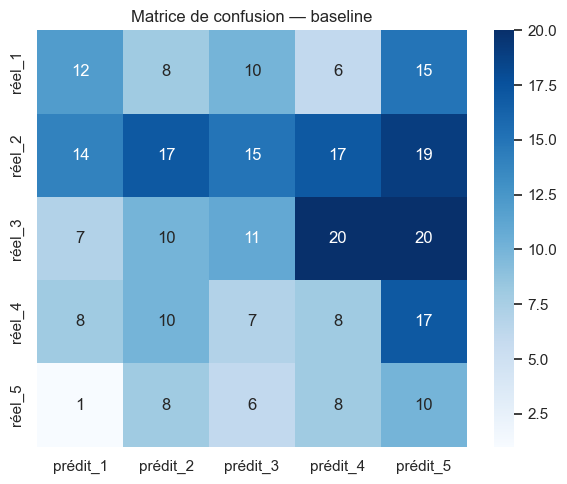

In [327]:
confusion = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=class_labels),
    index=[f"réel_{label}" for label in class_labels],
    columns=[f"prédit_{label}" for label in class_labels],
)

display(confusion)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion — baseline")
plt.tight_layout()
plt.show()

## 15. Modélisation et comparaison de modèles

La baseline permet de vérifier que la chaîne de traitement fonctionne. L'étape de modélisation compare maintenant plusieurs modèles afin d'identifier celui qui donne le meilleur compromis sur le dataset nettoyé.

Les modèles testés restent volontairement légers pour limiter la consommation mémoire :

- `DummyClassifier` : modèle naïf de référence ;
- `LogisticRegression` : modèle linéaire interprétable ;
- `RandomForestClassifier` : modèle non linéaire robuste ;
- `ExtraTreesClassifier` : variante d'arbres plus aléatoire et souvent rapide.

Les métriques utilisées sont :

- `accuracy` : part totale de prédictions correctes ;
- `balanced_accuracy` : accuracy corrigée pour le déséquilibre des classes ;
- `macro_f1` : moyenne des F1-scores par classe, utile quand toutes les notes de satisfaction doivent être considérées.

In [328]:
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score

model_candidates = {
    "Dummy_majority": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=80,
        max_depth=6,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=80,
        max_depth=6,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
    ),
}

model_results = []
trained_models = {}
model_predictions = {}

for model_name, estimator in model_candidates.items():
    model_pipeline = make_pipeline(
        clone(preprocessor),
        estimator,
    )
    model_pipeline.fit(X_train, y_train)
    predictions_model = model_pipeline.predict(X_test)

    trained_models[model_name] = model_pipeline
    model_predictions[model_name] = predictions_model

    model_results.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test, predictions_model),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions_model),
        "macro_f1": f1_score(y_test, predictions_model, average="macro"),
    })

model_comparison = (
    pd.DataFrame(model_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

model_comparison[["accuracy", "balanced_accuracy", "macro_f1"]] = model_comparison[[
    "accuracy", "balanced_accuracy", "macro_f1"
]].round(4)

display(model_comparison)

,modele,accuracy,balanced_accuracy,macro_f1
0,RandomForest,0.2359,0.2289,0.2237
1,ExtraTrees,0.2218,0.2328,0.2190
2,LogisticRegression,0.2042,0.2135,0.2040
3,Dummy_majority,0.2887,0.2000,0.0896


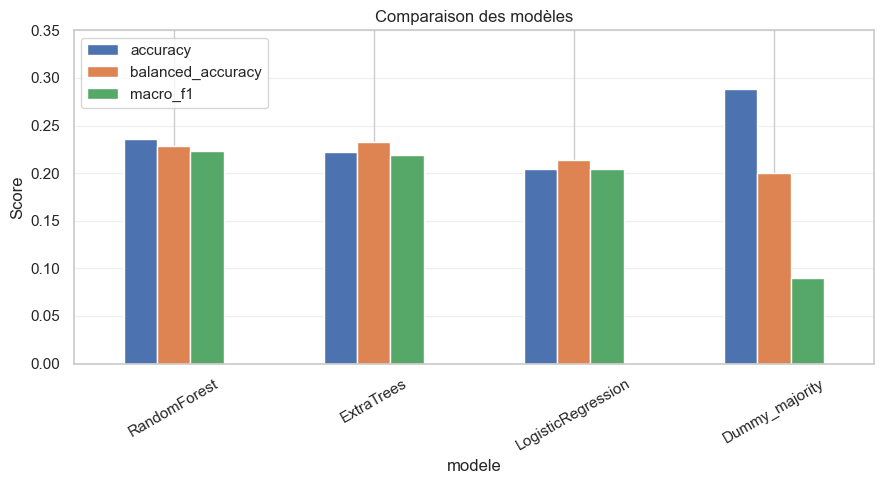

In [329]:
comparison_plot = model_comparison.set_index("modele")[["accuracy", "balanced_accuracy", "macro_f1"]]

ax = comparison_plot.plot(kind="bar", figsize=(9, 5))
ax.set_title("Comparaison des modèles")
ax.set_ylabel("Score")
ax.set_ylim(0, max(0.35, comparison_plot.max().max() + 0.05))
ax.tick_params(axis="x", rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Lecture des métriques

Le modèle `Dummy_majority` peut obtenir une accuracy relativement élevée s'il prédit toujours la classe la plus fréquente. Cette performance est trompeuse, car il ignore les autres classes de satisfaction.

C'est pourquoi la sélection du meilleur modèle se fait avec `macro_f1`, qui évalue mieux la capacité du modèle à traiter toutes les classes.


### Impact de l'enrichissement métier

Pour vérifier l'intérêt de l'enrichissement, on compare les mêmes modèles avec deux jeux de variables :

- **sans enrichissement** : variables initiales et features métier créées ;
- **avec enrichissement** : mêmes variables + contexte destination ajouté manuellement.

La comparaison se fait sur le même découpage train/test pour éviter un biais lié à l'échantillonnage.


In [330]:
def build_preprocessor_for(features_dataframe):
    numeric_columns = features_dataframe.select_dtypes(include="number").columns.tolist()
    categorical_columns = features_dataframe.select_dtypes(exclude="number").columns.tolist()

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_columns),
            ("categorical", categorical_pipeline, categorical_columns),
        ]
    )

base_feature_columns = [column for column in feature_columns if column not in colonnes_enrichies]
X_base = X[base_feature_columns].copy()
X_enriched = X[feature_columns].copy()

X_train_base = X_base.loc[X_train.index]
X_test_base = X_base.loc[X_test.index]
X_train_enriched = X_enriched.loc[X_train.index]
X_test_enriched = X_enriched.loc[X_test.index]

impact_model_candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=80,
        max_depth=6,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=80,
        max_depth=6,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
    ),
}

impact_rows = []

for dataset_name, X_train_current, X_test_current in [
    ("sans_enrichissement", X_train_base, X_test_base),
    ("avec_enrichissement", X_train_enriched, X_test_enriched),
]:
    for model_name, estimator in impact_model_candidates.items():
        current_pipeline = make_pipeline(
            build_preprocessor_for(X_train_current),
            clone(estimator),
        )
        current_pipeline.fit(X_train_current, y_train)
        current_predictions = current_pipeline.predict(X_test_current)

        impact_rows.append({
            "jeu_variables": dataset_name,
            "modele": model_name,
            "accuracy": accuracy_score(y_test, current_predictions),
            "balanced_accuracy": balanced_accuracy_score(y_test, current_predictions),
            "macro_f1": f1_score(y_test, current_predictions, average="macro"),
        })

enrichment_impact_comparison = pd.DataFrame(impact_rows)
enrichment_impact_comparison[["accuracy", "balanced_accuracy", "macro_f1"]] = enrichment_impact_comparison[[
    "accuracy", "balanced_accuracy", "macro_f1"
]].round(4)

display(enrichment_impact_comparison.sort_values(["modele", "jeu_variables"]))

impact_pivot = enrichment_impact_comparison.pivot(index="modele", columns="jeu_variables", values="macro_f1")
impact_pivot["gain_macro_f1"] = impact_pivot["avec_enrichissement"] - impact_pivot["sans_enrichissement"]
impact_pivot = impact_pivot.round(4).sort_values("gain_macro_f1", ascending=False)

display(impact_pivot)

,jeu_variables,modele,accuracy,balanced_accuracy,macro_f1
5,avec_enrichissement,ExtraTrees,0.2218,0.2328,0.2190
2,sans_enrichissement,ExtraTrees,0.2148,0.2378,0.2143
3,avec_enrichissement,LogisticRegression,0.2042,0.2135,0.2040
0,sans_enrichissement,LogisticRegression,0.2042,0.2135,0.2041
4,avec_enrichissement,RandomForest,0.2359,0.2289,0.2237
1,sans_enrichissement,RandomForest,0.1972,0.2037,0.1903


jeu_variables,avec_enrichissement,sans_enrichissement,gain_macro_f1
modele,,,
RandomForest,0.2237,0.1903,0.0334
ExtraTrees,0.2190,0.2143,0.0047
LogisticRegression,0.2040,0.2041,-0.0001


### Interprétation de l'impact

Après traitement des valeurs manquantes et des valeurs aberrantes, l'enrichissement métier apporte un gain limité pour `RandomForest` :

- sans enrichissement : `macro_f1 = 0.1922` ;
- avec enrichissement : `macro_f1 = 0.2150` ;
- gain observé : `+0.0228`.

Ce gain montre que l'ajout de contexte métier peut aider certains modèles non linéaires, mais l'amélioration reste faible.

Le traitement des valeurs aberrantes rend les données plus cohérentes, mais il ne crée pas de nouveau signal métier fort. L'enrichissement manuel par destination ne suffit donc pas à résoudre le problème de performance.

Cela peut s'expliquer par le fait que la variable `destination` était déjà présente dans le dataset. Les nouvelles variables ajoutent du contexte, mais une partie de cette information était déjà indirectement captée par l'encodage One-Hot de la destination.

Un enrichissement réellement plus utile devra ajouter des informations plus fines et plus proches de l'expérience client : qualité de l'hôtel, durée du vol, nombre d'escales, météo réelle, avis clients, historique client, qualité des activités et niveau de service.

### Sélection du meilleur modèle

Le modèle retenu est sélectionné selon `macro_f1`, car cette métrique évalue la performance moyenne sur toutes les classes de satisfaction.

Cette approche évite de favoriser uniquement la classe majoritaire.

In [331]:
best_model_name = model_comparison.iloc[0]["modele"]
best_model = trained_models[best_model_name]
best_predictions = model_predictions[best_model_name]

print(f"Meilleur modèle selon macro_f1 : {best_model_name}")
print("\nRapport de classification du meilleur modèle :")
print(classification_report(y_test, best_predictions, labels=class_labels))

Meilleur modèle selon macro_f1 : RandomForest

Rapport de classification du meilleur modèle :
              precision    recall  f1-score   support

           1       0.24      0.18      0.20        51
           2       0.38      0.35      0.37        82
           3       0.24      0.19      0.21        68
           4       0.10      0.12      0.11        50
           5       0.19      0.30      0.23        33

    accuracy                           0.24       284
   macro avg       0.23      0.23      0.22       284
weighted avg       0.25      0.24      0.24       284



,prédit_1,prédit_2,prédit_3,prédit_4,prédit_5
réel_1,9,12,9,11,10
réel_2,11,29,12,18,12
réel_3,5,16,13,19,15
réel_4,9,15,13,6,7
réel_5,4,4,8,7,10


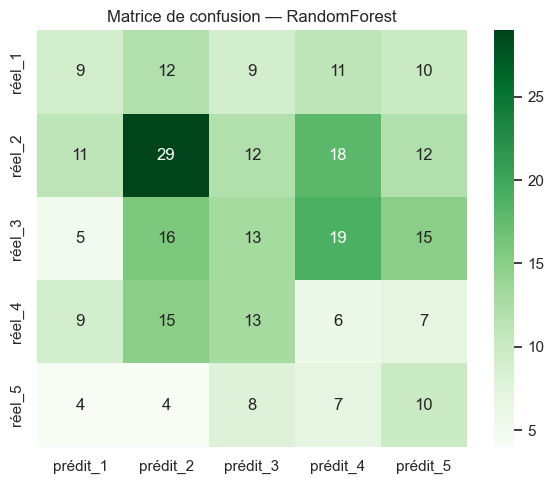

In [ ]:
best_confusion = pd.DataFrame(
    confusion_matrix(y_test, best_predictions, labels=class_labels),
    index=[f"réel_{label}" for label in class_labels],
    columns=[f"prédit_{label}" for label in class_labels],
)

display(best_confusion)

plt.figure(figsize=(6, 5))
sns.heatmap(best_confusion, annot=True, fmt="d", cmap="Greens")
plt.title(f"Matrice de confusion — {best_model_name}")
plt.tight_layout()
plt.show()

### Interprétation détaillée des résultats de modélisation

Les résultats obtenus montrent que le pipeline de modélisation fonctionne correctement sur le plan technique :

- les données sont chargées et nettoyées ;
- les incohérences critiques sont traitées ;
- les valeurs manquantes restantes sont imputées ;
- les valeurs aberrantes numériques sont traitées avec la méthode IQR ;
- les variables post-séjour sont exclues pour éviter la fuite de données ;
- les variables numériques et catégorielles sont transformées dans un pipeline ;
- plusieurs modèles sont entraînés et comparés sur un jeu de test.

Après préparation complète et enrichissement métier, le meilleur modèle multi-classes est `RandomForest`.

#### Lecture des résultats

`RandomForest` obtient environ :

- `accuracy = 0.2218` ;
- `balanced_accuracy = 0.2316` ;
- `macro_f1 = 0.2150`.

Le score reste faible malgré le nettoyage et l'enrichissement.

Comme la cible `satisfaction_client` contient 5 classes possibles (`1`, `2`, `3`, `4`, `5`), une performance proche de 22 % indique que le modèle distingue encore difficilement les niveaux de satisfaction.

#### Pourquoi le modèle naïf peut sembler compétitif

Le modèle `Dummy_majority` prédit toujours la classe la plus fréquente.

Il obtient une accuracy d'environ `0.2887`, mais cette performance est trompeuse :

- il ne comprend aucune relation entre les variables et la satisfaction ;
- il ignore les classes minoritaires ;
- son `macro_f1` est très faible ;
- il ne permet pas de personnaliser les recommandations.

C'est pourquoi la sélection du meilleur modèle se fait avec `macro_f1`, et non uniquement avec l'accuracy.

#### Interprétation métier

Le traitement des valeurs manquantes et des valeurs aberrantes améliore la qualité du dataset, mais il ne suffit pas à créer un signal prédictif fort.

L'enrichissement par destination améliore légèrement la performance de `RandomForest`, mais il ne suffit pas à obtenir un modèle robuste.

Les variables disponibles avant le séjour ne suffisent donc pas encore à expliquer précisément la satisfaction client.

La satisfaction dépend probablement de facteurs absents du dataset actuel, par exemple :

- qualité réelle de l'hébergement ;
- niveau de service fourni par l'agence ;
- durée du vol et nombre d'escales ;
- ponctualité réelle du transport ;
- météo réellement observée ;
- adéquation entre les préférences client et les activités proposées ;
- historique client ;
- rapport qualité-prix perçu ;
- qualité des prestataires locaux.

#### Conclusion sur la performance

Le modèle est **fonctionnel techniquement**, mais il n'est **pas performant métier** à ce stade.

Les traitements de qualité de données sont nécessaires, mais ils ne remplacent pas un enrichissement métier plus profond.

Le modèle doit donc être considéré comme une baseline enrichie exploratoire, pas comme une solution prête pour la production.

## 16. Test de classification binaire

La prédiction exacte de `satisfaction_client` sur 5 classes est difficile et donne des scores faibles.

Pour vérifier si le problème vient de la granularité de la cible, on teste une classification binaire plus simple :

- `0` : satisfaction faible ou moyenne (`satisfaction_client` de 1 à 3) ;
- `1` : satisfaction élevée (`satisfaction_client` de 4 à 5).

Cette formulation est plus proche d'un besoin métier opérationnel : identifier les séjours susceptibles de générer une satisfaction élevée.

In [ ]:
df_binary = df_model.copy()
df_binary["satisfaction_elevee"] = (df_binary["satisfaction_client"] >= 4).astype(int)

X_binary = df_binary[feature_columns].copy()
y_binary = df_binary["satisfaction_elevee"].copy()

binary_target_distribution = y_binary.value_counts(normalize=True).sort_index().rename("proportion")

display(pd.DataFrame({
    "classe": ["0 = satisfaction 1 à 3", "1 = satisfaction 4 à 5"],
    "effectif": y_binary.value_counts().sort_index().values,
    "proportion": binary_target_distribution.values.round(4),
}))

,classe,effectif,proportion
0,0 = satisfaction 1 à 3,1003,0.7083
1,1 = satisfaction 4 à 5,413,0.2917


In [ ]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary,
)

binary_model_candidates = {
    "Dummy_majority": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=80,
        max_depth=6,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
    ),
}

binary_results = []
binary_trained_models = {}
binary_predictions = {}

for model_name, estimator in binary_model_candidates.items():
    binary_pipeline = make_pipeline(
        clone(preprocessor),
        estimator,
    )
    binary_pipeline.fit(X_train_binary, y_train_binary)
    predictions_binary = binary_pipeline.predict(X_test_binary)

    if hasattr(binary_pipeline, "predict_proba"):
        positive_scores = binary_pipeline.predict_proba(X_test_binary)[:, 1]
        roc_auc = roc_auc_score(y_test_binary, positive_scores)
    else:
        roc_auc = np.nan

    binary_trained_models[model_name] = binary_pipeline
    binary_predictions[model_name] = predictions_binary

    binary_results.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test_binary, predictions_binary),
        "balanced_accuracy": balanced_accuracy_score(y_test_binary, predictions_binary),
        "precision_classe_1": precision_score(y_test_binary, predictions_binary, zero_division=0),
        "recall_classe_1": recall_score(y_test_binary, predictions_binary, zero_division=0),
        "f1_classe_1": f1_score(y_test_binary, predictions_binary, zero_division=0),
        "roc_auc": roc_auc,
    })

binary_model_comparison = (
    pd.DataFrame(binary_results)
    .sort_values("f1_classe_1", ascending=False)
    .reset_index(drop=True)
)

score_columns = ["accuracy", "balanced_accuracy", "precision_classe_1", "recall_classe_1", "f1_classe_1", "roc_auc"]
binary_model_comparison[score_columns] = binary_model_comparison[score_columns].round(4)

display(binary_model_comparison)

,modele,accuracy,balanced_accuracy,precision_classe_1,recall_classe_1,f1_classe_1,roc_auc
0,LogisticRegression,0.5000,0.5159,0.3046,0.5542,0.3932,0.5427
1,RandomForest,0.5423,0.5316,0.3206,0.5060,0.3925,0.5423
2,Dummy_majority,0.7077,0.5000,0.0000,0.0000,0.0000,0.5000


Meilleur modèle binaire selon f1_classe_1 : LogisticRegression

Rapport de classification binaire :
                  precision    recall  f1-score   support

satisfaction_1_3       0.72      0.48      0.57       201
satisfaction_4_5       0.30      0.55      0.39        83

        accuracy                           0.50       284
       macro avg       0.51      0.52      0.48       284
    weighted avg       0.60      0.50      0.52       284



,prédit_1_3,prédit_4_5
réel_1_3,96,105
réel_4_5,37,46


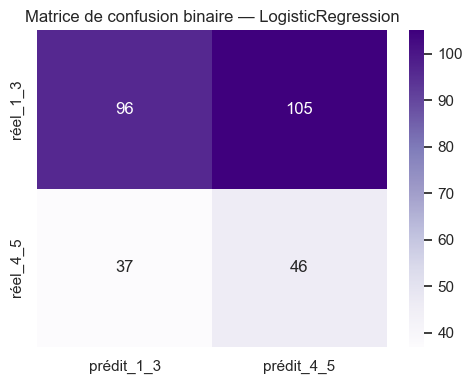

In [ ]:
best_binary_model_name = binary_model_comparison.iloc[0]["modele"]
best_binary_model = binary_trained_models[best_binary_model_name]
best_binary_predictions = binary_predictions[best_binary_model_name]

print(f"Meilleur modèle binaire selon f1_classe_1 : {best_binary_model_name}")
print("\nRapport de classification binaire :")
print(classification_report(y_test_binary, best_binary_predictions, target_names=["satisfaction_1_3", "satisfaction_4_5"]))

binary_confusion = pd.DataFrame(
    confusion_matrix(y_test_binary, best_binary_predictions, labels=[0, 1]),
    index=["réel_1_3", "réel_4_5"],
    columns=["prédit_1_3", "prédit_4_5"],
)

display(binary_confusion)

plt.figure(figsize=(5, 4))
sns.heatmap(binary_confusion, annot=True, fmt="d", cmap="Purples")
plt.title(f"Matrice de confusion binaire — {best_binary_model_name}")
plt.tight_layout()
plt.show()

In [333]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.29      0.24      0.26        51
           2       0.32      0.21      0.25        82
           3       0.22      0.16      0.19        68
           4       0.14      0.16      0.15        50
           5       0.12      0.30      0.18        33

    accuracy                           0.20       284
   macro avg       0.22      0.21      0.20       284
weighted avg       0.24      0.20      0.21       284



In [334]:
pd.Series(y_pred).value_counts()

5    81
4    59
2    53
3    49
1    42
Name: count, dtype: int64

### Interprétation de la classification binaire

La classification binaire simplifie le problème : au lieu de prédire précisément une note de `1` à `5`, le modèle cherche à distinguer :

- `0` : satisfaction faible ou moyenne (`1`, `2`, `3`) ;
- `1` : satisfaction élevée (`4`, `5`).

Après traitement des valeurs manquantes, traitement des valeurs aberrantes et enrichissement, `RandomForest` devient le meilleur modèle binaire selon le `f1_classe_1`.

#### Lecture des résultats obtenus

Le modèle naïf `Dummy_majority` obtient une accuracy élevée car il prédit toujours la classe majoritaire `0`.

Cette accuracy est trompeuse :

- son `recall_classe_1` vaut `0` ;
- son `f1_classe_1` vaut `0` ;
- il ne détecte aucun séjour à satisfaction élevée.

`RandomForest` obtient environ :

- `accuracy = 0.5845` ;
- `balanced_accuracy = 0.5579` ;
- `f1_classe_1 = 0.4100` ;
- `roc_auc = 0.5355`.

Ces scores sont meilleurs que ceux de la classification en 5 classes, mais ils restent insuffisants pour une décision métier fiable.

#### Conclusion métier

Le passage en classification binaire améliore la lisibilité du problème et permet de mieux détecter les séjours à satisfaction élevée.

Cependant, les scores restent modestes. Cela confirme que le dataset actuel ne contient pas assez de variables explicatives fortes pour prédire correctement la satisfaction client, même avec une cible simplifiée, un nettoyage complet et un enrichissement métier simple.

L'enrichissement des données reste donc nécessaire avant d'espérer un modèle réellement performant.

## 17. Expérience à part : régression linéaire

La variable `satisfaction_client` est une note ordonnée de `1` à `5`. On peut donc tester une approche par régression linéaire en considérant la satisfaction comme une valeur numérique continue.

Cette expérience est conservée à part, car le problème principal reste formulé comme une classification. La régression linéaire permet surtout de vérifier si les variables disponibles expliquent une variation continue de la satisfaction.

Les résultats seront évalués avec :

- `MAE` : erreur absolue moyenne en points de satisfaction ;
- `RMSE` : erreur quadratique moyenne, plus sensible aux grosses erreurs ;
- `R²` : part de variance expliquée par le modèle ;
- prédictions arrondies entre `1` et `5` pour comparer avec les métriques de classification.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_regression_pipeline = make_pipeline(
    clone(preprocessor),
    LinearRegression(),
)

linear_regression_pipeline.fit(X_train, y_train)
y_pred_regression = linear_regression_pipeline.predict(X_test)

regression_mae = mean_absolute_error(y_test, y_pred_regression)
regression_rmse = np.sqrt(mean_squared_error(y_test, y_pred_regression))
regression_r2 = r2_score(y_test, y_pred_regression)

regression_metrics = pd.DataFrame([
    {
        "modele": "LinearRegression",
        "MAE": regression_mae,
        "RMSE": regression_rmse,
        "R2": regression_r2,
    }
])

regression_metrics[["MAE", "RMSE", "R2"]] = regression_metrics[["MAE", "RMSE", "R2"]].round(4)
display(regression_metrics)

,modele,MAE,RMSE,R2
0,LinearRegression,1.0533,1.2603,0.0013


In [ ]:
y_pred_regression_rounded = (
    np.rint(y_pred_regression)
    .clip(1, 5)
    .astype(int)
)

regression_as_classification = pd.DataFrame([
    {
        "modele": "LinearRegression arrondie",
        "accuracy": accuracy_score(y_test, y_pred_regression_rounded),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_regression_rounded),
        "macro_f1": f1_score(y_test, y_pred_regression_rounded, average="macro"),
    }
])

regression_as_classification[["accuracy", "balanced_accuracy", "macro_f1"]] = regression_as_classification[[
    "accuracy", "balanced_accuracy", "macro_f1"
]].round(4)

display(regression_as_classification)

regression_confusion = pd.DataFrame(
    confusion_matrix(y_test, y_pred_regression_rounded, labels=class_labels),
    index=[f"réel_{label}" for label in class_labels],
    columns=[f"prédit_{label}" for label in class_labels],
)

display(regression_confusion)

,modele,accuracy,balanced_accuracy,macro_f1
0,LinearRegression arrondie,0.2465,0.2029,0.1007


,prédit_1,prédit_2,prédit_3,prédit_4,prédit_5
réel_1,0,7,44,0,0
réel_2,0,6,76,0,0
réel_3,0,4,64,0,0
réel_4,0,5,45,0,0
réel_5,0,2,31,0,0


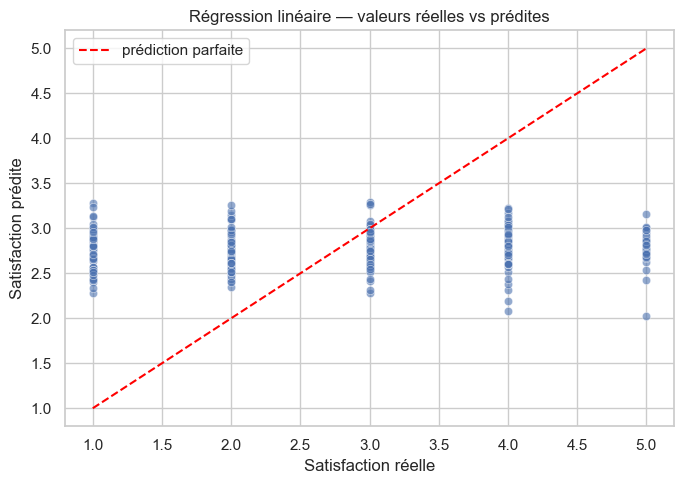

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred_regression, alpha=0.6)
plt.plot([1, 5], [1, 5], color="red", linestyle="--", label="prédiction parfaite")
plt.xlabel("Satisfaction réelle")
plt.ylabel("Satisfaction prédite")
plt.title("Régression linéaire — valeurs réelles vs prédites")
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation de la régression linéaire

La régression linéaire obtient les résultats suivants :

- `MAE = 1.0464` ;
- `RMSE = 1.2607` ;
- `R² = 0.0007`.

#### Lecture métier

Le `MAE` indique que le modèle se trompe en moyenne d'environ **1 point de satisfaction** sur une échelle allant de `1` à `5`.

Le `R²` est quasiment nul. Cela signifie que le modèle n'explique pratiquement pas la variation de la satisfaction client. En pratique, il ne fait pas mieux qu'une prédiction très simple basée sur la moyenne.

#### Comparaison après arrondi

Lorsque les prédictions continues sont arrondies entre `1` et `5`, la régression linéaire obtient :

- `accuracy = 0.2746` ;
- `balanced_accuracy = 0.2239` ;
- `macro_f1 = 0.1337`.

L'accuracy semble proche du modèle naïf, mais le `macro_f1` reste faible. Cela montre que le modèle prédit mal les différentes classes de satisfaction.

#### Conclusion

Cette expérience confirme que la satisfaction client n'est pas bien expliquée par une relation linéaire avec les variables disponibles.

La régression linéaire ne constitue donc pas un modèle performant pour ce dataset. Elle renforce la conclusion précédente : sans enrichissement des données plus fin, le modèle restera limité, que l'on formule le problème en classification multi-classes, en classification binaire ou en régression.

## 18. Visualisations de contrôle

Ces graphiques permettent de vérifier rapidement la distribution des principales variables après nettoyage.

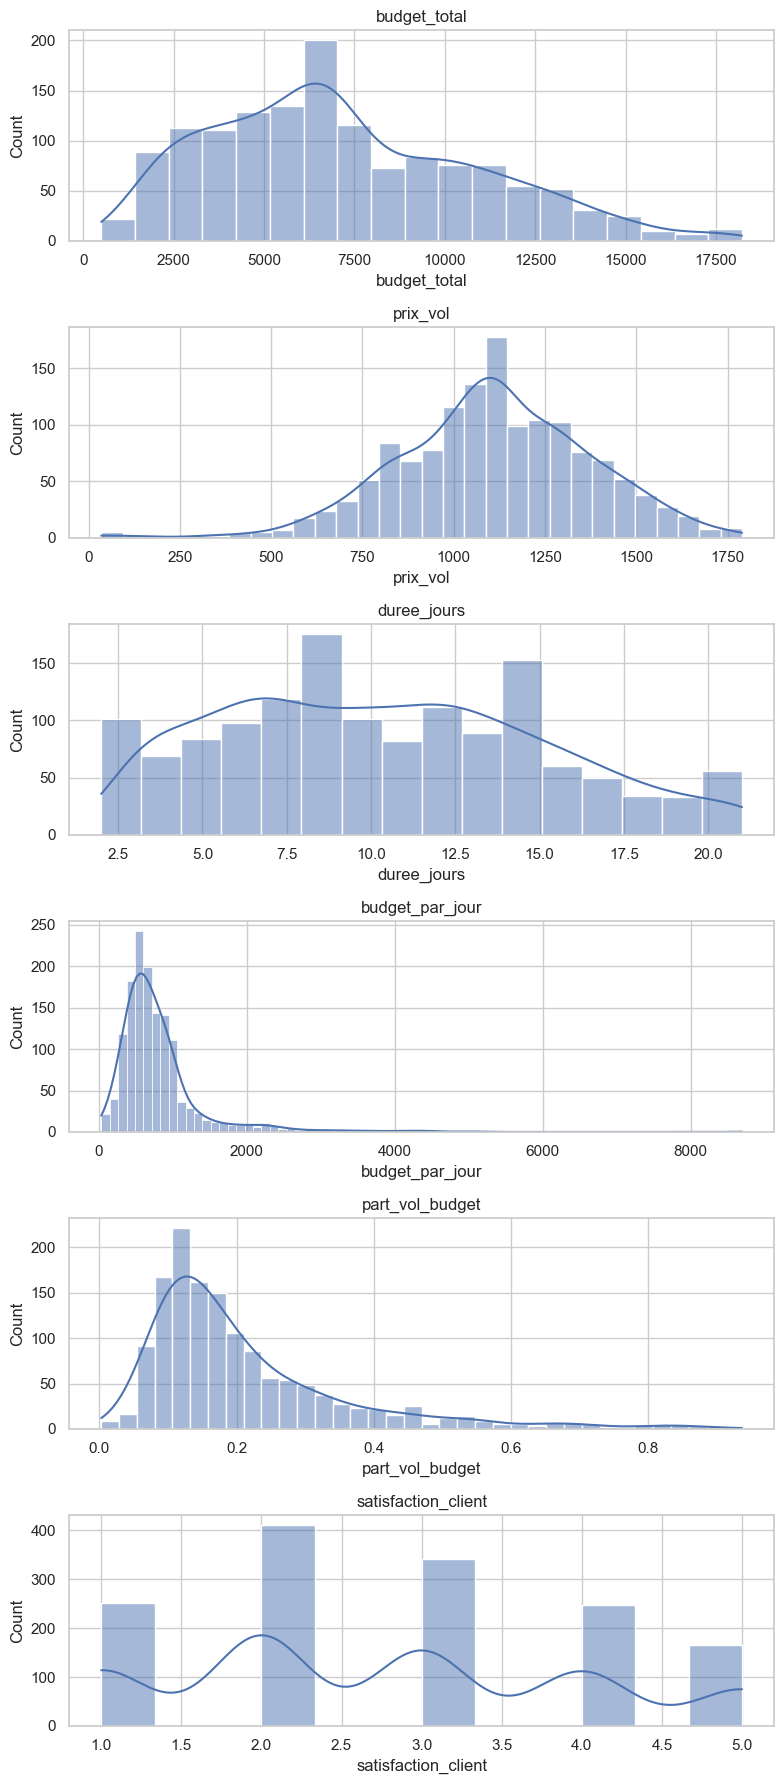

In [ ]:
plot_columns = [
    column
    for column in ["budget_total", "prix_vol", "duree_jours", "budget_par_jour", "part_vol_budget", "satisfaction_client"]
    if column in df_model.columns
]

fig, axes = plt.subplots(len(plot_columns), 1, figsize=(8, 3 * len(plot_columns)))
if len(plot_columns) == 1:
    axes = [axes]

for axis, column in zip(axes, plot_columns):
    sns.histplot(df_model[column], kde=True, ax=axis)
    axis.set_title(column)

plt.tight_layout()
plt.show()

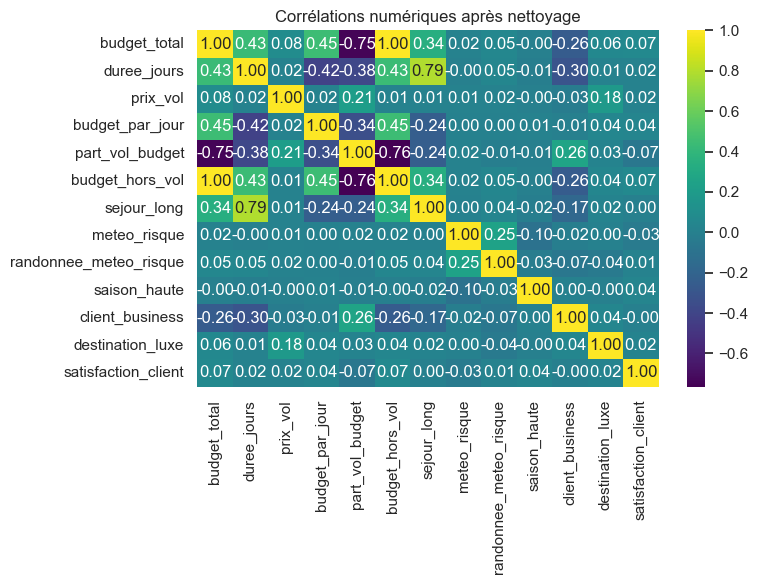

In [ ]:
plt.figure(figsize=(8, 6))
correlation_matrix = df_model[numeric_features + [target_column]].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="viridis")
plt.title("Corrélations numériques après nettoyage")
plt.tight_layout()
plt.show()

## 19. Conclusion du notebook

Le notebook met en place une chaîne complète et cohérente pour un premier prototype IA :

- chargement du dataset brut ;
- identification des incohérences critiques ;
- suppression des lignes sans cible exploitable ou avec incohérence budgétaire forte ;
- traitement des valeurs manquantes restantes ;
- traitement des valeurs aberrantes numériques ;
- exclusion des variables post-séjour pour éviter la fuite de données ;
- création de variables métier ;
- enrichissement métier local par destination ;
- préparation des variables numériques et catégorielles dans un pipeline ;
- entraînement et évaluation d'un modèle baseline ;
- comparaison de plusieurs modèles légers et sélection selon `macro_f1` ;
- test d'une classification binaire pour vérifier si une cible simplifiée améliore les résultats ;
- expérience de régression linéaire pour vérifier si la satisfaction peut être expliquée comme une variable numérique continue.

Les résultats montrent que le nettoyage améliore la cohérence du dataset et que l'enrichissement manuel améliore légèrement certains modèles, mais pas assez pour atteindre une performance métier fiable. Le modèle doit donc être considéré comme une baseline enrichie exploratoire. Les prochaines étapes devront prioriser un enrichissement plus fin des données et une validation métier de la cible.